In [1]:
import torch

In [2]:
import numpy as np
import nibabel as nib
import glob

# ── Paths ─────────────────────────────────────────────────────────────────────
REAL_DIR  = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/real/fields"
SYNTH_DIR = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/smooth_synthetic/train/b"

# ── Real DVFs ─────────────────────────────────────────────────────────────────
real_files = sorted(glob.glob(f"{REAL_DIR}/copd*.nii.gz"))
print(f"Found {len(real_files)} real DVF files.")

real_corr_xy, real_corr_xz, real_corr_yz = [], [], []
real_max, real_mean, real_std, real_p99   = [], [], [], []
real_dx_std, real_dy_std, real_dz_std     = [], [], []

for fpath in real_files:
    img  = nib.load(fpath)
    data = img.get_fdata(dtype=np.float32)  # (H, W, D, 3)
    mag  = np.linalg.norm(data, axis=-1)

    # exclude border voxels where registration forces motion to 0
    # use only voxels where magnitude > 1mm as a threshold
    mask = mag > 1.0
    dx = data[..., 0][mask].flatten()
    dy = data[..., 1][mask].flatten()
    dz = data[..., 2][mask].flatten()

    real_corr_xy.append(np.corrcoef(dx, dy)[0, 1])
    real_corr_xz.append(np.corrcoef(dx, dz)[0, 1])
    real_corr_yz.append(np.corrcoef(dy, dz)[0, 1])

    real_max.append(mag[mask].max())
    real_mean.append(mag[mask].mean())
    real_std.append(mag[mask].std())
    real_p99.append(np.percentile(mag[mask], 99))
    real_dx_std.append(dx.std())
    real_dy_std.append(dy.std())
    real_dz_std.append(dz.std())

# ── Synthetic DVFs ────────────────────────────────────────────────────────────
synth_files = sorted(glob.glob(f"{SYNTH_DIR}/field_*.npy"))[:50]
print(f"Found {len(synth_files)} synthetic DVF files (using first 50).")

synth_corr_xy, synth_corr_xz, synth_corr_yz = [], [], []
synth_max, synth_mean, synth_std, synth_p99  = [], [], [], []
synth_dx_std, synth_dy_std, synth_dz_std     = [], [], []

for fpath in synth_files:
    data = np.load(fpath)          # (3, H, W, D)
    data = data.transpose(1,2,3,0) # → (H, W, D, 3)
    mag  = np.linalg.norm(data, axis=-1)

    mask = mag > 1.0
    dx = data[..., 0][mask].flatten()
    dy = data[..., 1][mask].flatten()
    dz = data[..., 2][mask].flatten()

    synth_corr_xy.append(np.corrcoef(dx, dy)[0, 1])
    synth_corr_xz.append(np.corrcoef(dx, dz)[0, 1])
    synth_corr_yz.append(np.corrcoef(dy, dz)[0, 1])

    synth_max.append(mag[mask].max())
    synth_mean.append(mag[mask].mean())
    synth_std.append(mag[mask].std())
    synth_p99.append(np.percentile(mag[mask], 99))
    synth_dx_std.append(dx.std())
    synth_dy_std.append(dy.std())
    synth_dz_std.append(dz.std())

# ── Print results ─────────────────────────────────────────────────────────────
def fmt(vals):
    return f"{np.mean(vals):.2f} ({np.std(vals):.2f})"

print("\n=== Feature comparison: Real vs Synthetic (mean ± std across cases) ===")
print(f"{'Feature':<25} {'Real':>20} {'Synthetic':>20}")
print("-" * 67)
print(f"{'Max displacement (mm)':<25} {fmt(real_max):>20} {fmt(synth_max):>20}")
print(f"{'Mean displacement (mm)':<25} {fmt(real_mean):>20} {fmt(synth_mean):>20}")
print(f"{'Std displacement (mm)':<25} {fmt(real_std):>20} {fmt(synth_std):>20}")
print(f"{'p99 displacement (mm)':<25} {fmt(real_p99):>20} {fmt(synth_p99):>20}")
print(f"{'Std dx (mm)':<25} {fmt(real_dx_std):>20} {fmt(synth_dx_std):>20}")
print(f"{'Std dy (mm)':<25} {fmt(real_dy_std):>20} {fmt(synth_dy_std):>20}")
print(f"{'Std dz (mm)':<25} {fmt(real_dz_std):>20} {fmt(synth_dz_std):>20}")
print(f"{'corr(dx, dy)':<25} {fmt(real_corr_xy):>20} {fmt(synth_corr_xy):>20}")
print(f"{'corr(dx, dz)':<25} {fmt(real_corr_xz):>20} {fmt(synth_corr_xz):>20}")
print(f"{'corr(dy, dz)':<25} {fmt(real_corr_yz):>20} {fmt(synth_corr_yz):>20}")

Found 10 real DVF files.
Found 50 synthetic DVF files (using first 50).

=== Feature comparison: Real vs Synthetic (mean ± std across cases) ===
Feature                                   Real            Synthetic
-------------------------------------------------------------------
Max displacement (mm)            55.30 (13.35)         60.71 (8.76)
Mean displacement (mm)            21.65 (5.96)         16.20 (2.56)
Std displacement (mm)             11.00 (3.09)         10.56 (1.93)
p99 displacement (mm)            46.49 (11.49)         48.69 (8.08)
Std dx (mm)                        4.58 (1.23)          3.68 (0.29)
Std dy (mm)                        8.16 (3.14)          4.30 (0.51)
Std dz (mm)                       12.09 (3.88)         12.75 (2.01)
corr(dx, dy)                       0.10 (0.15)          0.02 (0.15)
corr(dx, dz)                      -0.08 (0.12)         -0.02 (0.75)
corr(dy, dz)                      -0.42 (0.10)         -0.22 (0.11)


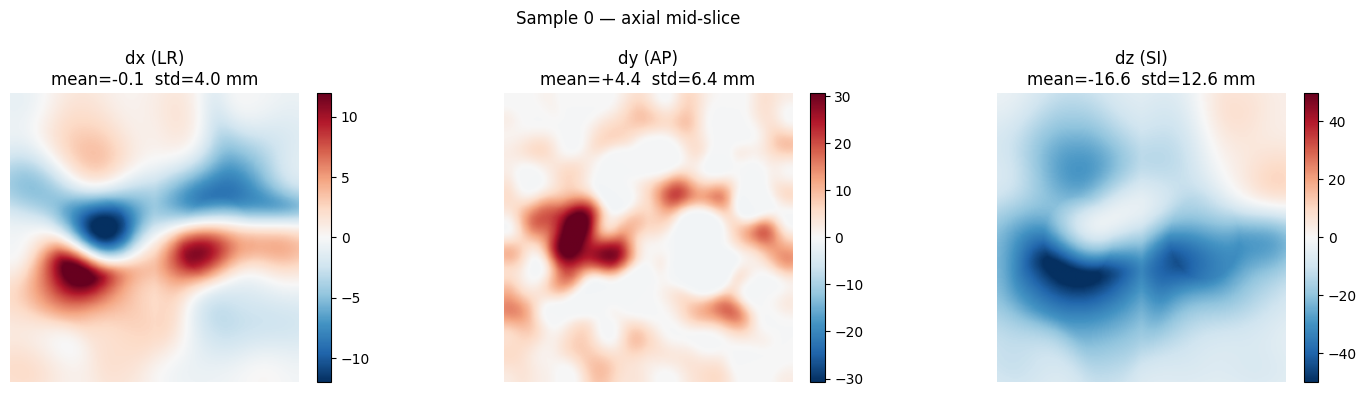

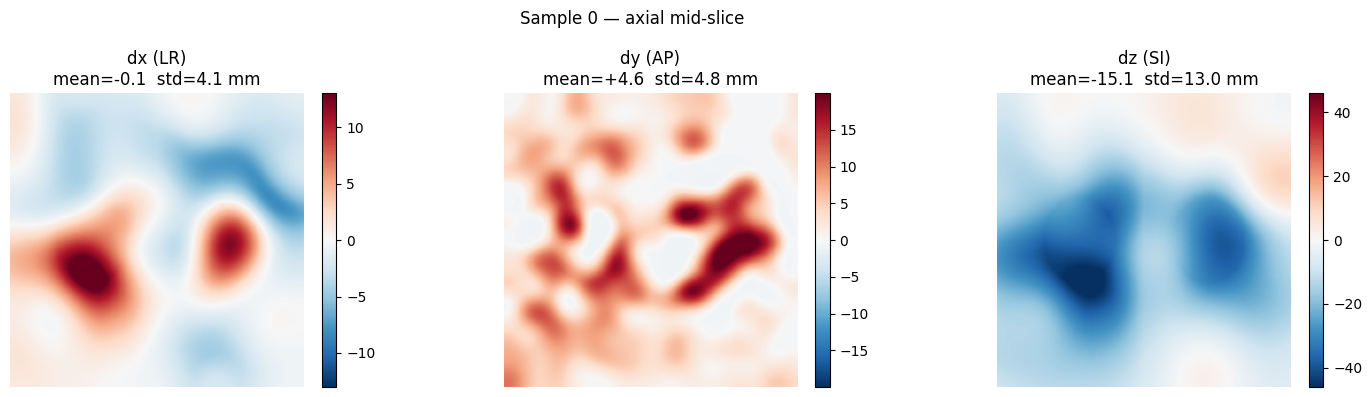

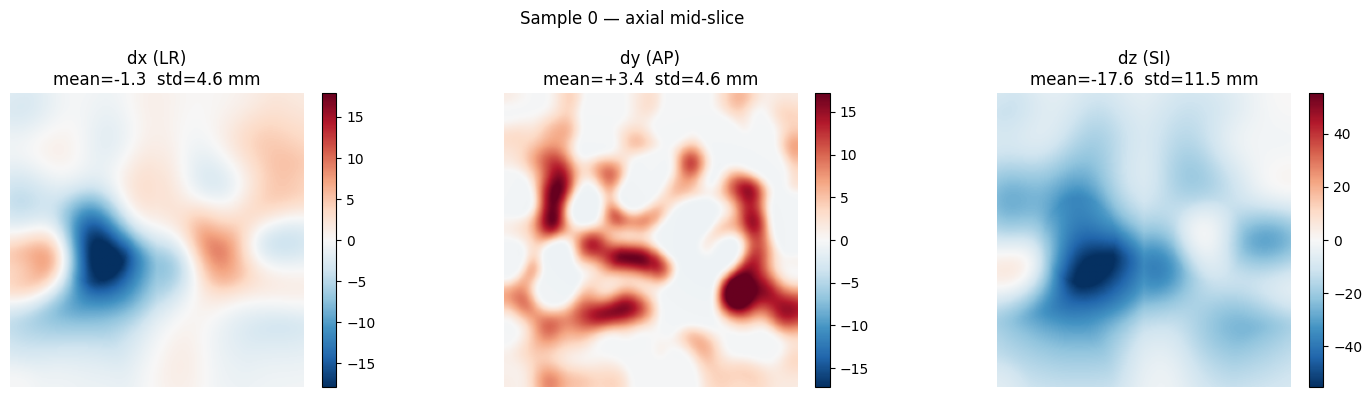

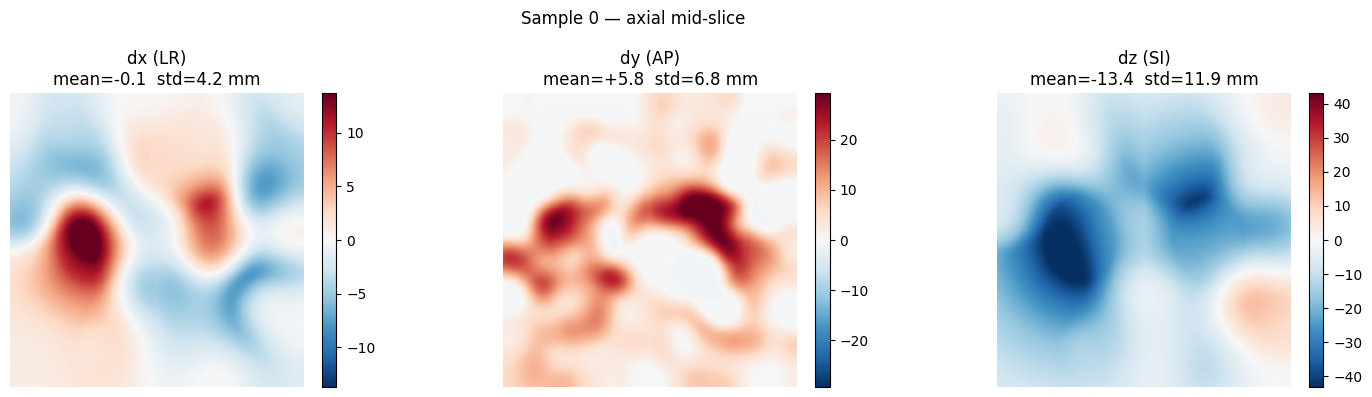

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load one sample
for i in range(4):
    dvf = np.load(f"/mimer/NOBACKUP/groups/caim1/dafne/datasets/smooth_synthetic/train/b/field_0000{i}.npy")
    # shape: (3, H, W, D)
    
    mid = dvf.shape[-1] // 2
    names = ["dx (LR)", "dy (AP)", "dz (SI)"]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for c, name in enumerate(names):
        sl = dvf[c, :, :, mid]
        vmax = np.percentile(np.abs(sl), 99)
        im = axes[c].imshow(sl.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')
        axes[c].set_title(f"{name}\nmean={sl.mean():+.1f}  std={sl.std():.1f} mm")
        axes[c].axis('off')
        plt.colorbar(im, ax=axes[c], fraction=0.046, pad=0.04)
    plt.suptitle("Sample 0 — axial mid-slice", fontsize=12)
    plt.tight_layout()
    plt.show()

In [4]:
import numpy as np

field_path = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/synthetic/train/b/field_00000.npy"
slice_path = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/synthetic/train/a/slice_00000.npy"

dvf = np.load(field_path)
slices = np.load(slice_path, allow_pickle=True).item()

print("=== DVF ===")
print(f"shape:  {dvf.shape}")
print(f"dtype:  {dvf.dtype}")
print(f"min:    {dvf.min():.4f}")
print(f"max:    {dvf.max():.4f}")
print(f"mean:   {dvf.mean():.4f}")
print(f"std:    {dvf.std():.4f}")

print("\n=== Slices dict keys ===")
print(list(slices.keys()))

print("\n=== Slices indices ===")
print(slices['indices'])

for k, v in slices.items():
    if k != 'indices':
        arr = np.array(v)
        print(f"\nslices['{k}'] shape: {arr.shape}")
        print(f"  min={arr.min():.4f}  max={arr.max():.4f}")

=== DVF ===
shape:  (3, 256, 256, 128)
dtype:  float32
min:    -40.5826
max:    52.7122
mean:   -0.1726
std:    10.5622

=== Slices dict keys ===
['coronal', 'sagittal', 'axial', 'indices']

=== Slices indices ===
{'mid_h': 128, 'mid_w': 128, 'mid_d': 64}

slices['coronal'] shape: (3, 256, 128)
  min=-19.4057  max=34.2965

slices['sagittal'] shape: (3, 256, 128)
  min=-39.8882  max=52.4330

slices['axial'] shape: (3, 256, 256)
  min=-34.6004  max=50.6894


In [5]:
test_field_dir = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/synthetic/test/b"
test_slice_dir = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/synthetic/test/a"

print("=== test field_dir ===")
test_field_files = sorted(os.listdir(test_field_dir))
print(f"Total: {len(test_field_files)}")
print(f"First 3: {test_field_files[:3]}")

print("\n=== test slice_dir ===")
test_slice_files = sorted(os.listdir(test_slice_dir))
print(f"Total: {len(test_slice_files)}")
print(f"First 3: {test_slice_files[:3]}")

# also check one test field to confirm same shape
dvf_test = np.load(os.path.join(test_field_dir, test_field_files[0]))
print(f"\nTest DVF shape: {dvf_test.shape}")
print(f"Test DVF min: {dvf_test.min():.4f}  max: {dvf_test.max():.4f}")

=== test field_dir ===
Total: 100
First 3: ['field_00000.npy', 'field_00001.npy', 'field_00002.npy']

=== test slice_dir ===
Total: 100
First 3: ['slice_00000.npy', 'slice_00001.npy', 'slice_00002.npy']

Test DVF shape: (3, 256, 256, 128)
Test DVF min: -58.6034  max: 35.2362


In [6]:
# check indices across first 10 samples
for i in range(10):
    s = np.load(
        f"/mimer/NOBACKUP/groups/caim1/dafne/datasets/synthetic/train/a/slice_{i:05d}.npy",
        allow_pickle=True
    ).item()
    print(f"sample {i:02d}: {s['indices']}")

sample 00: {'mid_h': 128, 'mid_w': 128, 'mid_d': 64}
sample 01: {'mid_h': 128, 'mid_w': 128, 'mid_d': 64}
sample 02: {'mid_h': 128, 'mid_w': 128, 'mid_d': 64}
sample 03: {'mid_h': 128, 'mid_w': 128, 'mid_d': 64}
sample 04: {'mid_h': 128, 'mid_w': 128, 'mid_d': 64}
sample 05: {'mid_h': 128, 'mid_w': 128, 'mid_d': 64}
sample 06: {'mid_h': 128, 'mid_w': 128, 'mid_d': 64}
sample 07: {'mid_h': 128, 'mid_w': 128, 'mid_d': 64}
sample 08: {'mid_h': 128, 'mid_w': 128, 'mid_d': 64}
sample 09: {'mid_h': 128, 'mid_w': 128, 'mid_d': 64}


In [7]:
# check value distribution more carefully across 20 random samples
import numpy as np
import os
import random

field_dir = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/synthetic/train/b"
files = sorted(os.listdir(field_dir))
random.seed(42)
sample_files = random.sample(files, 20)

all_mins, all_maxs, all_stds = [], [], []
for f in sample_files:
    dvf = np.load(os.path.join(field_dir, f))
    all_mins.append(dvf.min())
    all_maxs.append(dvf.max())
    all_stds.append(dvf.std())

print(f"Across 20 random train samples:")
print(f"  min of mins:  {min(all_mins):.4f}")
print(f"  max of maxs:  {max(all_maxs):.4f}")
print(f"  mean std:     {sum(all_stds)/len(all_stds):.4f}")
print(f"  max std:      {max(all_stds):.4f}")

# also check per-channel stats on one sample
dvf0 = np.load(os.path.join(field_dir, files[0]))
print(f"\nPer-channel stats for sample 0 (shape {dvf0.shape}):")
for c in range(3):
    print(f"  channel {c}: min={dvf0[c].min():.3f}  max={dvf0[c].max():.3f}  std={dvf0[c].std():.3f}")

# and check the test set max range
test_dir = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/synthetic/test/b"
test_files = sorted(os.listdir(test_dir))
test_maxs = []
for f in test_files[:20]:
    dvf = np.load(os.path.join(test_dir, f))
    test_maxs.append(abs(dvf).max())
print(f"\nTest set: max absolute value across first 20: {max(test_maxs):.4f}")

Across 20 random train samples:
  min of mins:  -66.4486
  max of maxs:  60.2611
  mean std:     11.6187
  max std:      14.1370

Per-channel stats for sample 0 (shape (3, 256, 256, 128)):
  channel 0: min=-18.064  max=15.121  std=3.633
  channel 1: min=-0.886  max=52.712  std=8.834
  channel 2: min=-40.583  max=9.186  std=8.167

Test set: max absolute value across first 20: 68.9498


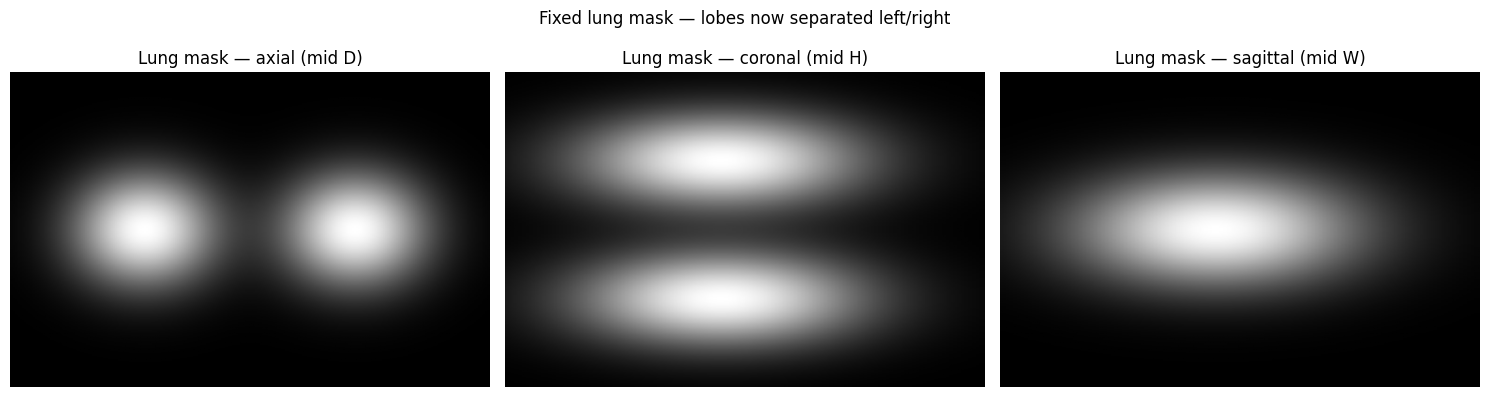

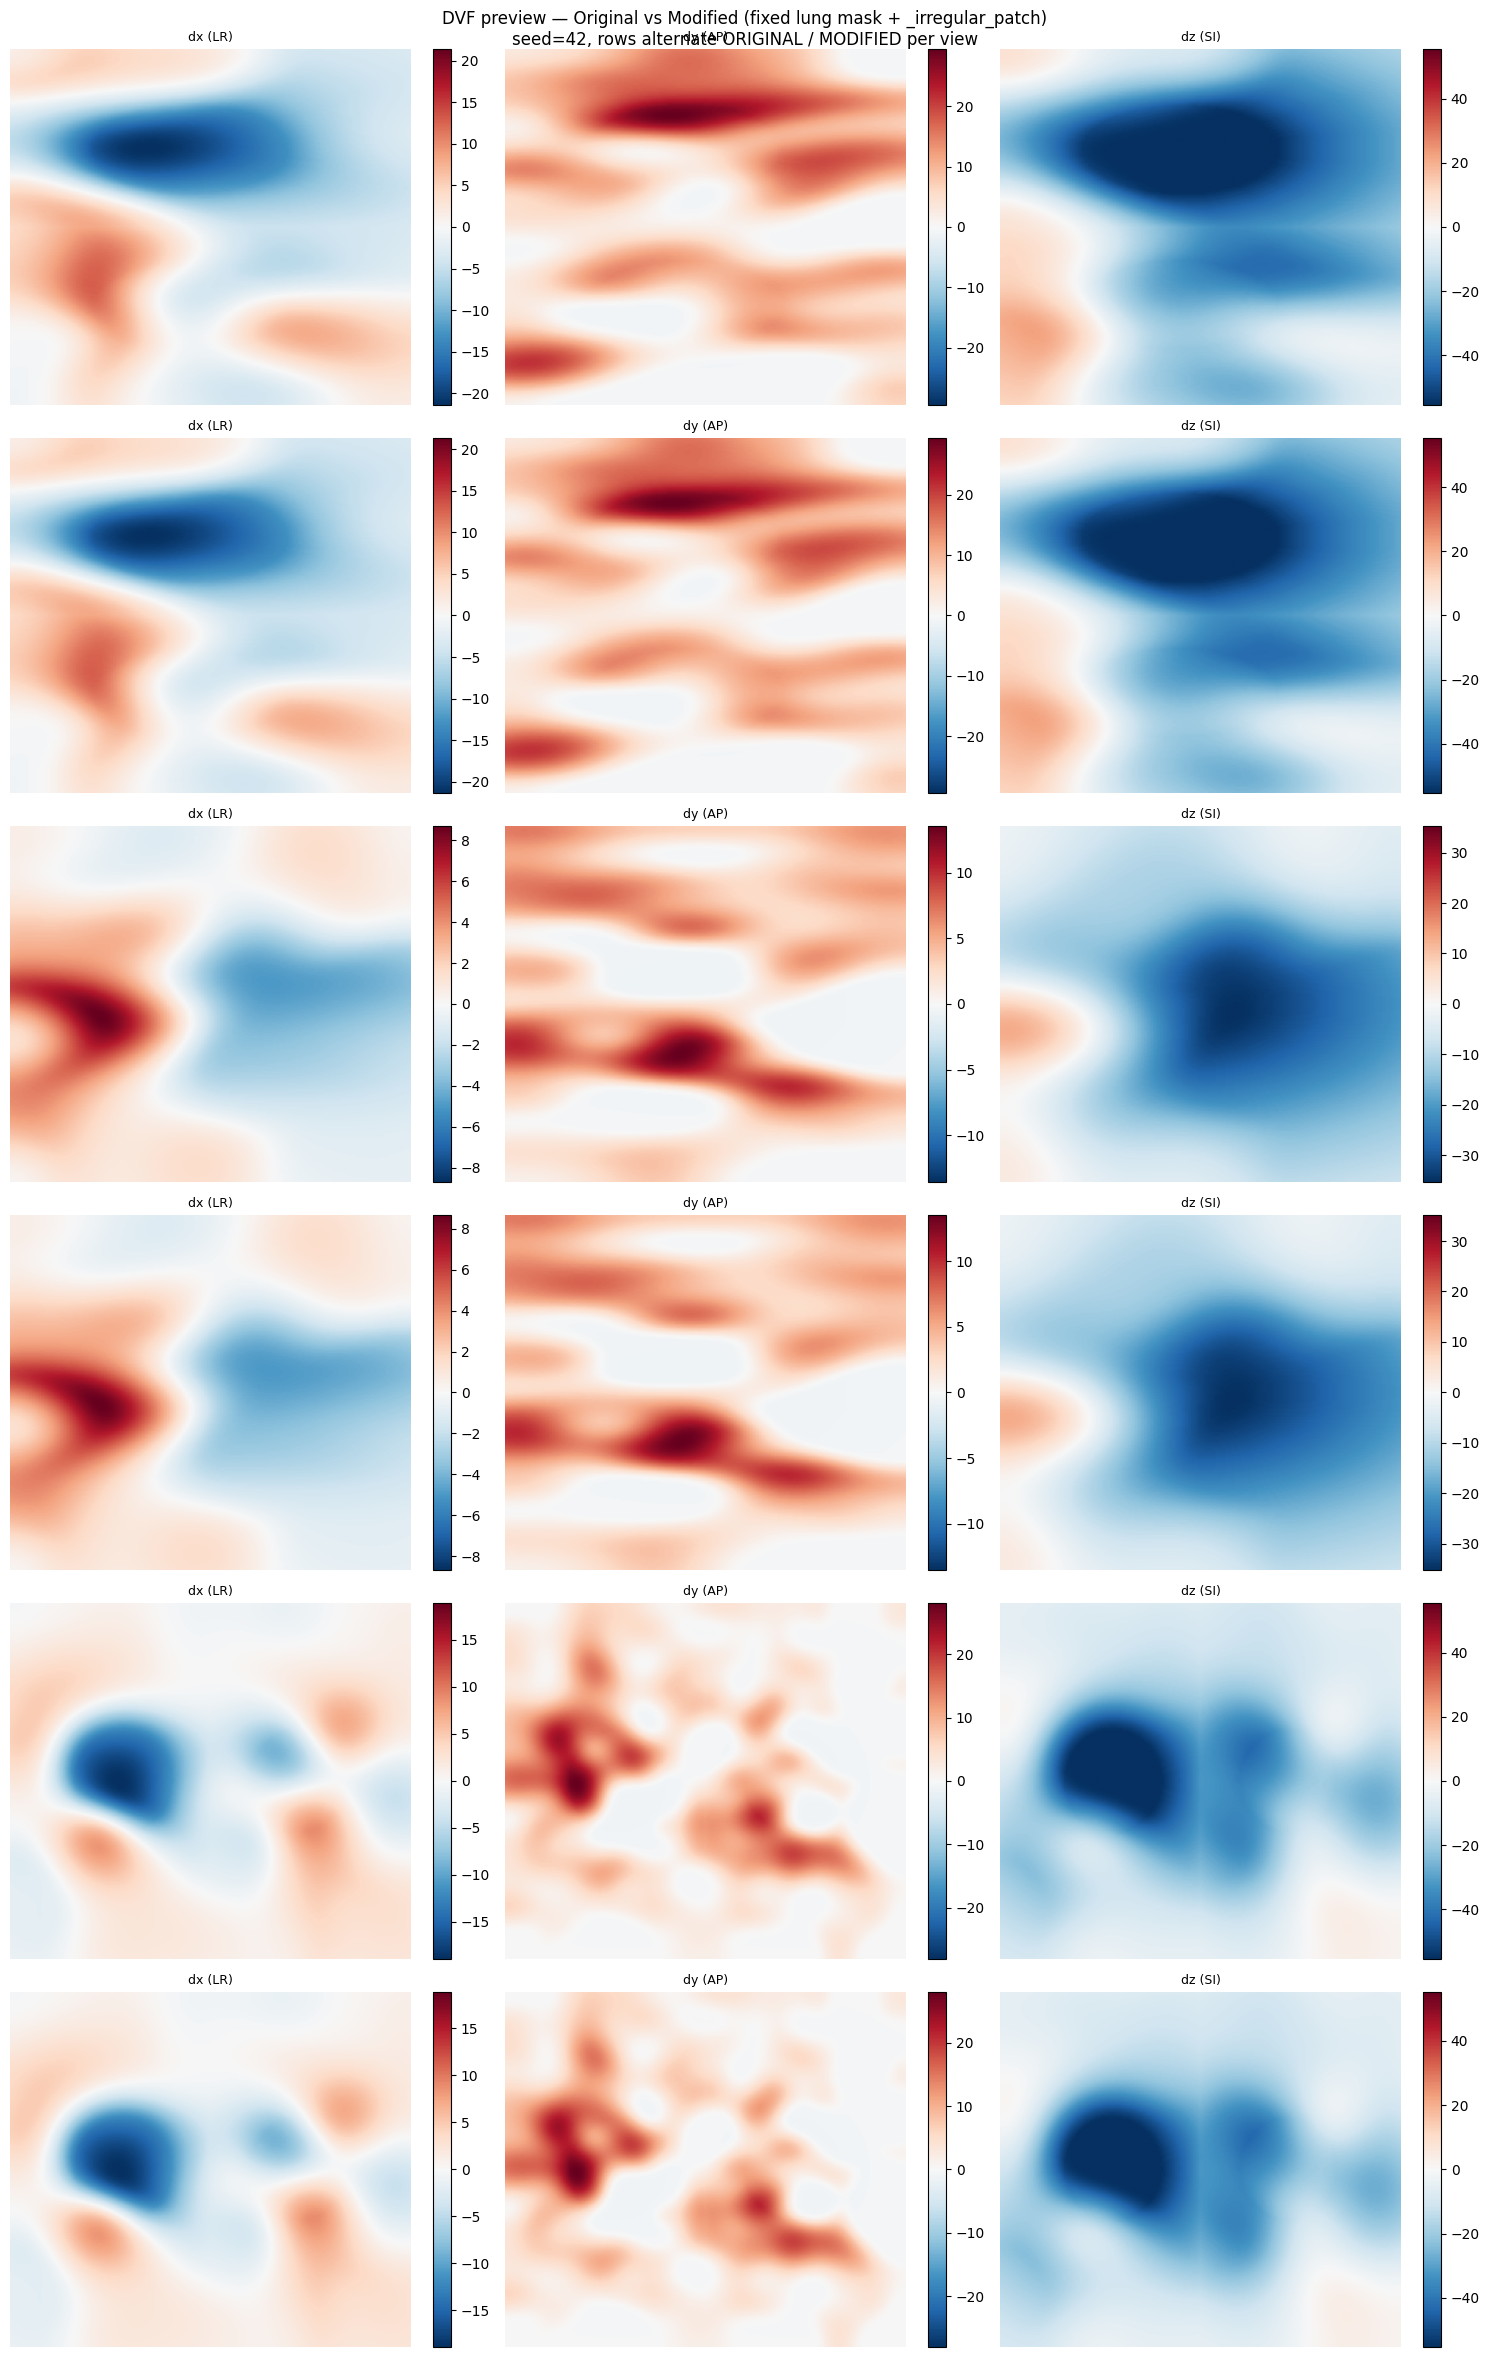

Saved to /mimer/NOBACKUP/groups/caim1/dafne/visual/dvf_preview_comparison.png

── Stats comparison ───────────────────────────────────────────
  dx  ORIG: mean= -0.17  std= 4.12  min= -21.37  max=+15.51
       MOD:  mean= -0.17  std= 4.12  min= -21.37  max=+15.51
  dy  ORIG: mean= +3.82  std= 4.56  min=  -0.89  max=+30.20
       MOD:  mean= +3.82  std= 4.56  min=  -0.89  max=+30.20
  dz  ORIG: mean=-14.26  std=12.91  min= -55.30  max=+22.67
       MOD:  mean=-14.26  std=12.91  min= -55.30  max=+22.67


In [1]:
# ── DVF Preview: Original vs Fixed lung mask + Modified _irregular_patch ───────
import os
DATA_DIR  = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/synthetic"
SAVE_DIR  = '/mimer/NOBACKUP/groups/caim1/dafne/checkpoints'
VIS_DIR   = '/mimer/NOBACKUP/groups/caim1/dafne/visual'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(VIS_DIR,  exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, zoom, distance_transform_edt

TARGET_H, TARGET_W, TARGET_D = 256, 256, 128
VOXEL_SPACING = np.array([0.625, 0.625, 2.5])

BEST_PARAMS = {
    "dx_amp_mid":         4.600120083746177,
    "dx_amp_range":       2.2307202291798696,
    "dx_final_mid":       5.785035594274386,
    "dx_final_range":     1.0016255130143858,
    "dx_scale_xy":        0.08464117081239977,
    "dx_scale_z":         0.18389863384342217,
    "dx_sigma_xy":        4.440869682680044,
    "dx_sigma_z":         3.549173758546373,
    "dx_mask_blend":      0.5595341165401964,
    "dy_global_mid":      13.92300086342907,
    "dy_global_range":    7.147343174155115,
    "dy_upper_mid":       3.8605946888437552,
    "dy_upper_range":     3.4967040074387064,
    "dy_tex_amp_mid":     2.8615676118068034,
    "dy_tex_amp_range":   1.2929712994720288,
    "dy_final_mid":       15.45641821509185,
    "dy_final_range":     2.7979233812976645,
    "dy_tex_scale_xy":    0.04245019165986802,
    "dy_tex_scale_z":     0.11878493509233237,
    "dy_sigma_xy":        9.445708297660333,
    "dy_sigma_z":         3.536359506225657,
    "dy_clip_lo":        -1.4180407612586232,
    "dz_max_mid":         16.550798679741778,
    "dz_max_range":       11.987788587157493,
    "dz_diag_mid":        5.778559956681235,
    "dz_diag_range":      3.426610382726605,
    "dz_patch_mid":       7.902055238568681,
    "dz_patch_range":     5.044436849301348,
    "dz_scale_xy":        0.0993956694420997,
    "dz_scale_z":         0.14657860966706757,
    "dz_sigma_xy":        3.1819976222354405,
    "dz_sigma_z":         1.1817841682383317,
    "dz_clip_neg_mult":   1.0101849062939523,
    "dz_clip_pos_mult":   0.5910514479089909,
    "final_smooth_dx":    1.0527499802410345,
    "final_smooth_dy":    1.9094213842997223,
    "final_smooth_dz":    3.4962417458890016,
    "boundary_ramp_width": 17.321939479672448,
    "dx_amp_lo":          3.484759969156242,
    "dx_amp_hi":          5.715480198336111,
    "dx_final_amp_lo":    10.158304214477539,
    "dx_final_amp_hi":    12.083813667297363,
    "dy_global_lo":       1.4846445322036743,
    "dy_global_hi":       2.5099542140960693,
    "dy_upper_lo":        2.112242685124402,
    "dy_upper_hi":        5.608946692563109,
    "dy_tex_amp_lo":      2.215081962070789,
    "dy_tex_amp_hi":      3.508053261542818,
    "dy_final_amp_lo":    13.00830078125,
    "dy_final_amp_hi":    20.184856414794922,
    "dz_max_lo":          14.787049293518066,
    "dz_max_hi":          31.578336715698242,
    "dz_diag_lo":         4.065254765317933,
    "dz_diag_hi":         7.491865148044537,
    "dz_patch_amp_lo":    5.379836813918008,
    "dz_patch_amp_hi":    10.424273663219354,
    "dx_coupling_strength": 0.6,
}

# ── ONLY CHANGE: lobes now separated along gx (left-right in imshow) ──────────
def make_lung_mask(H, W, D):
    ys = np.linspace(0, 1, H)
    xs = np.linspace(0, 1, W)
    zs = np.linspace(0, 1, D)
    gy, gx, gz = np.meshgrid(ys, xs, zs, indexing='ij')
    left  = np.exp(-((gy - 0.50)**2 / 0.18**2 + (gx - 0.28)**2 / 0.15**2))
    right = np.exp(-((gy - 0.50)**2 / 0.18**2 + (gx - 0.72)**2 / 0.15**2))
    mask_xy = np.clip(left + right, 0, 1)
    mask_z  = np.exp(-((gz - 0.45)**2 / 0.30**2))
    return (mask_xy * mask_z).astype(np.float32)

# ── Exact copy of TunableDVFGenerator from generate_dataset.py ────────────────
class TunableDVFGenerator:
    def __init__(self, shape, voxel_spacing, params):
        self.H, self.W, self.D = shape
        self.voxel_spacing     = np.array(voxel_spacing)
        self.p                 = params
        ys = np.linspace(0, 1, self.H)
        xs = np.linspace(0, 1, self.W)
        zs = np.linspace(0, 1, self.D)
        self.grid_y, self.grid_x, self.grid_z = np.meshgrid(
            ys, xs, zs, indexing='ij')
        self.diaphragm_grad  = self.grid_z.astype(np.float32)
        self.lung_mask       = make_lung_mask(self.H, self.W, self.D)
        self.boundary_weight = self._make_boundary_weight()

    def _make_boundary_weight(self):
        lung_binary  = self.lung_mask > 0.5
        dist_outside = distance_transform_edt(~lung_binary).astype(np.float32)
        ramp_width   = max(2.0, self.H * 15.0 / 64.0)
        weight       = np.exp(-dist_outside / ramp_width)
        weight[lung_binary] = 1.0
        return weight.astype(np.float32)

    def _irregular_patch(self, scale_xy, scale_z, amplitude,
                     sigma_xy, sigma_z, n_layers=2):
        field = np.zeros((self.H, self.W, self.D), dtype=np.float32)
        for _ in range(n_layers):
            seed   = np.random.randn(self.H, self.W, self.D).astype(np.float32)  # full res, no zoom
            sig_xy = self.H * scale_xy
            sig_z  = self.D * scale_z
            layer  = gaussian_filter(seed, sigma=(sig_xy, sig_xy, sig_z))
            layer /= (layer.std() + 1e-8)                                         # std norm, not abs max
            field += layer
        field /= (field.std() + 1e-8)                                             # std norm, not abs max
        return (field * amplitude).astype(np.float32)

    def generate(self):
        p = self.p
        dx_main = self._irregular_patch(
            scale_xy=p["dx_scale_xy"], scale_z=p["dx_scale_z"],
            amplitude=np.random.uniform(p["dx_amp_lo"], p["dx_amp_hi"]),
            sigma_xy=p["dx_sigma_xy"], sigma_z=p["dx_sigma_z"], n_layers=3)
        dx = dx_main * (p["dx_mask_blend"] + (1.0 - p["dx_mask_blend"]) * self.lung_mask)
        dx_target_std = np.random.uniform(p["dx_final_amp_lo"], p["dx_final_amp_hi"])
        dx = dx / (dx.std() + 1e-8) * dx_target_std

        dy_global    = np.random.uniform(p["dy_global_lo"], p["dy_global_hi"])
        upper_weight = (1.0 - self.grid_y) * (1.0 - self.grid_x)
        dy_upper     = upper_weight * np.random.uniform(p["dy_upper_lo"], p["dy_upper_hi"])
        dy_texture   = self._irregular_patch(
            scale_xy=p["dy_tex_scale_xy"], scale_z=p["dy_tex_scale_z"],
            amplitude=np.random.uniform(p["dy_tex_amp_lo"], p["dy_tex_amp_hi"]),
            sigma_xy=p["dy_sigma_xy"] * 3.0, sigma_z=p["dy_sigma_z"] * 3.0, n_layers=2)
        dy = dy_global + dy_upper + dy_texture
        dy_texture_component = dy - dy_global
        dy_tex_target_std = np.random.uniform(p["dy_final_amp_lo"], p["dy_final_amp_hi"])
        dy_texture_component = dy_texture_component / (dy_texture_component.std() + 1e-8) \
                               * dy_tex_target_std
        dy = dy_global + dy_texture_component
        dy = np.clip(dy, p["dy_clip_lo"], None)

        dz_max  = np.random.uniform(p["dz_max_lo"], p["dz_max_hi"])
        dz_base = -dz_max * self.diaphragm_grad
        a = np.random.uniform(0.3, 0.7)
        b = np.random.uniform(0.3, 0.7)
        diag = a * self.grid_y + b * self.grid_x
        diag = (diag - diag.mean()) / (diag.std() + 1e-8)
        dz_diag  = diag * np.random.uniform(p["dz_diag_lo"], p["dz_diag_hi"])
        dz_patch = self._irregular_patch(
            scale_xy=p["dz_scale_xy"], scale_z=p["dz_scale_z"],
            amplitude=np.random.uniform(p["dz_patch_amp_lo"], p["dz_patch_amp_hi"]),
            sigma_xy=p["dz_sigma_xy"], sigma_z=p["dz_sigma_z"], n_layers=3)
        dz = dz_base + dz_diag + dz_patch
        dz = np.clip(dz, -dz_max * p["dz_clip_neg_mult"], dz_max * p["dz_clip_pos_mult"])

        flow = np.stack([dx, dy, dz], axis=-1)
        for c, sig in enumerate([p["final_smooth_dx"], p["final_smooth_dy"], p["final_smooth_dz"]]):
            flow[..., c] = gaussian_filter(flow[..., c], sigma=sig)
        for c in range(3):
            flow[..., c] *= self.boundary_weight
        flow *= self.voxel_spacing[np.newaxis, np.newaxis, np.newaxis, :]
        return flow.astype(np.float32)

# ── Exact copy of FixedDXDVFGenerator from generate_dataset.py ────────────────
class FixedDXDVFGenerator(TunableDVFGenerator):
    def generate(self):
        p = self.p

        dy_global    = np.random.uniform(p["dy_global_lo"], p["dy_global_hi"])
        upper_weight = (1.0 - self.grid_y) * (1.0 - self.grid_x)
        dy_upper     = upper_weight * np.random.uniform(p["dy_upper_lo"], p["dy_upper_hi"])
        dy_texture   = self._irregular_patch(
            scale_xy=p["dy_tex_scale_xy"], scale_z=p["dy_tex_scale_z"],
            amplitude=np.random.uniform(p["dy_tex_amp_lo"], p["dy_tex_amp_hi"]),
            sigma_xy=p["dy_sigma_xy"] * 3.0, sigma_z=p["dy_sigma_z"] * 3.0, n_layers=2)
        dy = dy_global + dy_upper + dy_texture
        dy_texture_component = dy - dy_global
        dy_tex_target_std = np.random.uniform(p["dy_final_amp_lo"], p["dy_final_amp_hi"])
        dy_texture_component = (dy_texture_component / (dy_texture_component.std() + 1e-8)
                                * dy_tex_target_std)
        dy = dy_global + dy_texture_component
        dy = np.clip(dy, p["dy_clip_lo"], None)

        dz_max  = np.random.uniform(p["dz_max_lo"], p["dz_max_hi"])
        dz_base = -dz_max * self.diaphragm_grad
        a = np.random.uniform(0.3, 0.7)
        b = np.random.uniform(0.3, 0.7)
        diag = a * self.grid_y + b * self.grid_x
        diag = (diag - diag.mean()) / (diag.std() + 1e-8)
        dz_diag  = diag * np.random.uniform(p["dz_diag_lo"], p["dz_diag_hi"])
        dz_patch = self._irregular_patch(
            scale_xy=p["dz_scale_xy"], scale_z=p["dz_scale_z"],
            amplitude=np.random.uniform(p["dz_patch_amp_lo"], p["dz_patch_amp_hi"]),
            sigma_xy=p["dz_sigma_xy"], sigma_z=p["dz_sigma_z"], n_layers=3)
        dz = dz_base + dz_diag + dz_patch
        dz = np.clip(dz, -dz_max * p["dz_clip_neg_mult"], dz_max * p["dz_clip_pos_mult"])

        dz_norm = np.abs(dz) / (np.abs(dz).max() + 1e-8)
        dz_norm = gaussian_filter(dz_norm, sigma=3.0)
        sign    = np.random.choice([-1, 1])
        dx_corr = sign * dz_norm
        if dx_corr.std() > 1e-8:
            dx_corr = dx_corr / dx_corr.std()
        dx_noise = self._irregular_patch(
            scale_xy=p["dx_scale_xy"], scale_z=p["dx_scale_z"],
            amplitude=1.0, sigma_xy=p["dx_sigma_xy"] * 3.0,
            sigma_z=p["dx_sigma_z"] * 3.0, n_layers=2)
        if dx_noise.std() > 1e-8:
            dx_noise = dx_noise / dx_noise.std()
        gamma = 0.70
        dx = gamma * dx_corr + (1.0 - gamma) * dx_noise
        dx = dx * (p["dx_mask_blend"] + (1.0 - p["dx_mask_blend"]) * self.lung_mask)
        dx_target_std = np.random.uniform(p["dx_final_amp_lo"], p["dx_final_amp_hi"])
        dx = dx / (dx.std() + 1e-8) * dx_target_std
        dx_mean_target = np.random.uniform(-2.0, 0.0)
        dx = dx - dx.mean() + dx_mean_target

        flow = np.stack([dx, dy, dz], axis=-1)
        for c, sig in enumerate([4.0, p["final_smooth_dy"], p["final_smooth_dz"]]):
            flow[..., c] = gaussian_filter(flow[..., c], sigma=sig)
        for c in range(3):
            flow[..., c] *= self.boundary_weight
        flow *= self.voxel_spacing[np.newaxis, np.newaxis, np.newaxis, :]
        return flow.astype(np.float32)

# ── Modified version: only _irregular_patch changes ───────────────────────────
class FixedDXDVFGeneratorModified(FixedDXDVFGenerator):
    def _irregular_patch(self, scale_xy, scale_z, amplitude,
                         sigma_xy, sigma_z, n_layers=2):
        field = np.zeros((self.H, self.W, self.D), dtype=np.float32)
        for _ in range(n_layers):
            seed   = np.random.randn(self.H, self.W, self.D).astype(np.float32)
            sig_xy = self.H * scale_xy
            sig_z  = self.D * scale_z
            layer  = gaussian_filter(seed, sigma=(sig_xy, sig_xy, sig_z))
            layer /= (layer.std() + 1e-8)
            field += layer
        field /= (field.std() + 1e-8)
        return (field * amplitude).astype(np.float32)

# ── Generate one sample each with the same seed ───────────────────────────────
gen_orig = FixedDXDVFGenerator(
    shape=(TARGET_H, TARGET_W, TARGET_D),
    voxel_spacing=VOXEL_SPACING,
    params=BEST_PARAMS
)
gen_mod = FixedDXDVFGeneratorModified(
    shape=(TARGET_H, TARGET_W, TARGET_D),
    voxel_spacing=VOXEL_SPACING,
    params=BEST_PARAMS
)

np.random.seed(42); dvf_orig = gen_orig.generate()
np.random.seed(42); dvf_mod  = gen_mod.generate()

mid_h = TARGET_H // 2
mid_w = TARGET_W // 2
mid_d = TARGET_D // 2

# ── Figure 1: lung mask + boundary weight (quick sanity check) ─────────────────
fig_mask, axes_mask = plt.subplots(1, 3, figsize=(15, 4))
axes_mask[0].imshow(gen_orig.lung_mask[:, :, mid_d], cmap="gray", aspect="auto")
axes_mask[0].set_title("Lung mask — axial (mid D)")
axes_mask[0].axis("off")
axes_mask[1].imshow(gen_orig.lung_mask[mid_h, :, :], cmap="gray", aspect="auto")
axes_mask[1].set_title("Lung mask — coronal (mid H)")
axes_mask[1].axis("off")
axes_mask[2].imshow(gen_orig.lung_mask[:, mid_w, :], cmap="gray", aspect="auto")
axes_mask[2].set_title("Lung mask — sagittal (mid W)")
axes_mask[2].axis("off")
plt.suptitle("Fixed lung mask — lobes now separated left/right", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "lung_mask_fixed.png"), dpi=120, bbox_inches="tight")
plt.show()

# ── Figure 2: DVF comparison — exact same layout as the cell you sent ──────────
channel_names = ["dx (LR)", "dy (AP)", "dz (SI)"]
view_labels   = ["Coronal  (mid H)", "Sagittal (mid W)", "Axial    (mid D)"]

def extract_slices(dvf, mh, mw, md):
    return [
        dvf[mh, :, :, :],   # coronal  (W, D, 3)
        dvf[:, mw, :, :],   # sagittal (H, D, 3)
        dvf[:, :, md, :],   # axial    (H, W, 3)
    ]

slices_orig = extract_slices(dvf_orig, mid_h, mid_w, mid_d)
slices_mod  = extract_slices(dvf_mod,  mid_h, mid_w, mid_d)

fig, axes = plt.subplots(6, 3, figsize=(15, 24))

for view_i, view_label in enumerate(view_labels):
    row_orig = view_i * 2
    row_mod  = view_i * 2 + 1
    for ch in range(3):
        o    = slices_orig[view_i][..., ch]
        m    = slices_mod[view_i][..., ch]
        vabs = max(np.abs(o).max(), np.abs(m).max())

        im0 = axes[row_orig, ch].imshow(o, cmap="RdBu_r", vmin=-vabs, vmax=vabs, aspect="auto")
        axes[row_orig, ch].set_title(channel_names[ch], fontsize=9)
        axes[row_orig, ch].axis("off")
        plt.colorbar(im0, ax=axes[row_orig, ch], fraction=0.046)

        im1 = axes[row_mod, ch].imshow(m, cmap="RdBu_r", vmin=-vabs, vmax=vabs, aspect="auto")
        axes[row_mod, ch].set_title(channel_names[ch], fontsize=9)
        axes[row_mod, ch].axis("off")
        plt.colorbar(im1, ax=axes[row_mod, ch], fraction=0.046)

        if ch == 0:
            axes[row_orig, ch].set_ylabel(f"ORIGINAL\n{view_label}", fontsize=8)
            axes[row_mod,  ch].set_ylabel(f"MODIFIED\n{view_label}", fontsize=8)

plt.suptitle("DVF preview — Original vs Modified (fixed lung mask + _irregular_patch)\n"
             "seed=42, rows alternate ORIGINAL / MODIFIED per view", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "dvf_preview_comparison.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved to {VIS_DIR}/dvf_preview_comparison.png")

# ── Stats ──────────────────────────────────────────────────────────────────────
print("\n── Stats comparison ───────────────────────────────────────────")
for c, name in enumerate(["dx", "dy", "dz"]):
    o = dvf_orig[..., c]
    m = dvf_mod[..., c]
    print(f"  {name}  ORIG: mean={o.mean():+6.2f}  std={o.std():5.2f}  "
          f"min={o.min():+7.2f}  max={o.max():+6.2f}")
    print(f"       MOD:  mean={m.mean():+6.2f}  std={m.std():5.2f}  "
          f"min={m.min():+7.2f}  max={m.max():+6.2f}")

In [4]:
import os
import glob
import numpy as np
from tqdm import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable  # ADD THIS IMPORT

# ── Fix orientation of existing dataset in-place ───────────────────────────────
# The lung mask was generated with lobes along axis 0 (H) instead of axis 1 (W)
# Fix: swap H and W axes in DVF fields and coronal/sagittal slices

DATA_DIR = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/smooth_synthetic"

for split in ["train", "test"]:
    field_dir = os.path.join(DATA_DIR, split, "b")
    slice_dir = os.path.join(DATA_DIR, split, "a")

    field_files = sorted(glob.glob(os.path.join(field_dir, "field_*.npy")))
    print(f"\nFixing {len(field_files)} samples in {split}...")

    for field_path in tqdm(field_files):
        idx = os.path.basename(field_path).replace("field_", "").replace(".npy", "")
        slice_path = os.path.join(slice_dir, f"slice_{idx}.npy")

        # ── Fix DVF field: (3, H, W, D) → swap H and W → (3, W, H, D) ──────
        dvf = np.load(field_path)           # (3, H, W, D)
        dvf = dvf.transpose(0, 2, 1, 3)    # (3, W, H, D) — swap axes 1 and 2
        np.save(field_path, dvf)

        # ── Fix slices ────────────────────────────────────────────────────────
        slices = np.load(slice_path, allow_pickle=True).item()

        H, W, D   = dvf.shape[1], dvf.shape[2], dvf.shape[3]
        mid_h     = H // 2
        mid_w     = W // 2
        mid_d     = D // 2

        # recompute slices from the corrected DVF
        new_slices = {
            "coronal":  dvf[:, mid_h, :, :],   # (3, W, D)
            "sagittal": dvf[:, :, mid_w, :],   # (3, H, D)
            "axial":    dvf[:, :, :, mid_d],   # (3, H, W)
            "indices":  {"mid_h": mid_h, "mid_w": mid_w, "mid_d": mid_d}
        }
        np.save(slice_path, new_slices)

print("\nDone — dataset fixed in-place.")

# ── Quick sanity check on one sample ──────────────────────────────────────────
s = np.load(os.path.join(DATA_DIR, "train/b/field_00000.npy"))
print(f"\nSanity check:")
print(f"  DVF shape : {s.shape}")
print(f"  dx: mean={s[0].mean():+.2f}  std={s[0].std():.2f}")
print(f"  dy: mean={s[1].mean():+.2f}  std={s[1].std():.2f}")
print(f"  dz: mean={s[2].mean():+.2f}  std={s[2].std():.2f}")


Fixing 500 samples in train...


  1%|▍                                          | 5/500 [00:06<11:15,  1.36s/it]


KeyboardInterrupt: 

In [5]:
import os
import math
import random
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR    = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/smooth_synthetic_downsampled"
CKPT_DIR    = "/mimer/NOBACKUP/groups/caim1/dafne/checkpoints"
RESULTS_DIR = "/mimer/NOBACKUP/groups/caim1/dafne/results/prova"
os.makedirs(RESULTS_DIR, exist_ok=True)

VOXEL_SPACING = (1.25, 1.25, 5.0)

# ── Dataset ───────────────────────────────────────────────────────────────────
class SyntheticDVFDataset(Dataset):
    def __init__(self, root_dir, split="test"):
        self.field_dir = os.path.join(root_dir, split, "b")
        self.slice_dir = os.path.join(root_dir, split, "a")
        self.ids = sorted([
            f.split("_")[1].split(".")[0]
            for f in os.listdir(self.field_dir)
            if f.startswith("field_")
        ])
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, idx):
        i = self.ids[idx]
        dvf    = np.load(os.path.join(self.field_dir, f"field_{i}.npy"))
        slices = np.load(os.path.join(self.slice_dir,  f"slice_{i}.npy"),
                         allow_pickle=True).item()
        cond_coronal  = slices["coronal"]
        cond_sagittal = slices["sagittal"]
        mid_d         = slices["indices"]["mid_d"]
        dvf           = torch.from_numpy(dvf).float()
        cond_coronal  = torch.from_numpy(cond_coronal).float()
        cond_sagittal = torch.from_numpy(cond_sagittal).float()
        D             = dvf.shape[-1]
        slice_pos     = mid_d / (D - 1)
        return cond_coronal, cond_sagittal, dvf, slice_pos

# ── Model ─────────────────────────────────────────────────────────────────────
class DiffusionSchedule:
    def __init__(self, timesteps=1000, device="cpu"):
        self.timesteps = timesteps
        self.betas     = torch.linspace(1e-4, 0.02, timesteps).to(device)
        self.alphas    = 1.0 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_bar           = torch.sqrt(self.alpha_bar)
        self.sqrt_one_minus_alphas_bar = torch.sqrt(1. - self.alpha_bar)

    def q_sample(self, x0, t, noise):
        sqrt_ab           = self.sqrt_alphas_bar[t][:, None, None, None, None]
        sqrt_one_minus_ab = self.sqrt_one_minus_alphas_bar[t][:, None, None, None, None]
        return sqrt_ab * x0 + sqrt_one_minus_ab * noise

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half_dim = self.dim // 2
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -(math.log(10000) / (half_dim - 1)))
        emb = t[:, None] * emb[None, :] * 2 * math.pi
        return torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)

class SliceToVolume(nn.Module):
    def __init__(self, out_channels=16):
        super().__init__()
        self.coronal_encoder  = nn.Sequential(nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.Conv2d(16, out_channels, 3, padding=1))
        self.sagittal_encoder = nn.Sequential(nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.Conv2d(16, out_channels, 3, padding=1))
        self.fusion = nn.Conv3d(out_channels, out_channels, 3, padding=1)
    def forward(self, coronal, sagittal, D):
        B = coronal.shape[0]; W = coronal.shape[2]; H = sagittal.shape[2]
        cor_feat = self.coronal_encoder(coronal)
        sag_feat = self.sagittal_encoder(sagittal)
        cor_vol  = cor_feat.permute(0,1,3,2).unsqueeze(3).expand(-1,-1,-1,H,-1)
        sag_vol  = sag_feat.permute(0,1,3,2).unsqueeze(4).expand(-1,-1,-1,-1,W)
        return F.relu(self.fusion(cor_vol + sag_vol))

class ResidualBlock3D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(channels, channels, 3, padding=1), nn.GroupNorm(8, channels), nn.ReLU(),
            nn.Conv3d(channels, channels, 3, padding=1), nn.GroupNorm(8, channels))
    def forward(self, x):
        return F.relu(x + self.block(x))

class UNet3D_Diffusion(nn.Module):
    def __init__(self, cond_channels=16):
        super().__init__()
        self.time_mlp      = nn.Sequential(TimeEmbedding(64), nn.Linear(64, 64), nn.ReLU())
        self.time_proj1    = nn.Linear(64, 32)
        self.time_proj2    = nn.Linear(64, 64)
        self.time_proj_mid = nn.Linear(64, 64)
        self.enc1 = nn.Conv3d(3 + cond_channels, 32, 3, padding=1)
        self.enc2 = nn.Conv3d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool3d(2)
        self.mid     = nn.Conv3d(64, 64, 3, padding=1)
        self.mid_res = ResidualBlock3D(64)
        self.dec1 = nn.ConvTranspose3d(64, 32, 2, stride=2)
        self.out  = nn.Conv3d(32, 3, 3, padding=1)
    def forward(self, x, cond, t):
        x    = x.permute(0,1,4,2,3).contiguous()
        cond = cond.permute(0,1,2,3,4).contiguous()
        t    = t.float() / 1000.0
        t_emb = self.time_mlp(t)
        x     = torch.cat([x, cond], dim=1)
        scale1 = self.time_proj1(t_emb)[:,:,None,None,None]
        x1 = F.relu(self.enc1(x) * (1 + scale1))
        x2 = F.relu(self.enc2(self.pool(x1)) + self.time_proj2(t_emb)[:,:,None,None,None])
        x_mid = F.relu(self.mid(x2) + self.time_proj_mid(t_emb)[:,:,None,None,None])
        x_mid = self.mid_res(x_mid)
        x = self.dec1(x_mid) + x1
        x = self.out(x)
        return x.permute(0,1,3,4,2).contiguous()

class DiffusionModelManager(nn.Module):
    def __init__(self, cond_channels=16):
        super().__init__()
        self.slice_to_vol = SliceToVolume(out_channels=cond_channels)
        self.unet         = UNet3D_Diffusion(cond_channels=cond_channels)
    def forward(self, x_t, coronal_2d, sagittal_2d, t):
        D       = x_t.shape[-1]
        cond_3d = self.slice_to_vol(coronal_2d, sagittal_2d, D)
        return self.unet(x_t, cond_3d, t)

# ── Plot function ─────────────────────────────────────────────────────────────

def plot_fig2(si, all_gts, all_preds, mid_d, mid_h, mid_w,
                     results_dir, method_name="DDPM"):

    component_names = ["dx (LR)", "dy (AP)", "dz (SI)"]
    col_titles = ["Ax GT", "Ax Pred", "Cor GT", "Cor Pred", "Sag GT", "Sag Pred"]

    fig, axes = plt.subplots(3, 6, figsize=(18, 9))

    # column titles
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=10, fontweight='bold')

    for c, cname in enumerate(component_names):
        gt_c   = all_gts[si, c].numpy()
        pred_c = all_preds[si, c].numpy()

        slices = [
            (gt_c[:, :, mid_d],  pred_c[:, :, mid_d]),
            (gt_c[mid_h, :, :],  pred_c[mid_h, :, :]),
            (gt_c[:, mid_w, :],  pred_c[:, mid_w, :]),
        ]

        vmax = max(np.abs(gt_c).max(), np.abs(pred_c).max())
        vmax = vmax if vmax > 0 else 1.0

        for v, (gt_sl, pred_sl) in enumerate(slices):
            col_gt = v * 2
            col_pr = v * 2 + 1

            im_gt = axes[c, col_gt].imshow(
                gt_sl, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto'
            )
            axes[c, col_gt].axis('off')

            im_pr = axes[c, col_pr].imshow(
                pred_sl, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto'
            )
            axes[c, col_pr].axis('off')

        # row label
        axes[c, 0].set_ylabel(cname, fontsize=11)

        # ✅ FIXED COLORBAR (this replaces your old one)
        divider = make_axes_locatable(axes[c, -1])
        cax = divider.append_axes("right", size="3%", pad=0.05)
        fig.colorbar(im_pr, cax=cax)

    plt.suptitle(
        f"Sample {si} — DVF Components (GT vs {method_name})\n"
        f"(z={mid_d}, h={mid_h}, w={mid_w})",
        fontsize=13,
        fontweight='bold'
    )

    # ✅ KEEP THIS (no tight_layout!)
    plt.subplots_adjust(top=0.92, wspace=0.05, hspace=0.1)

    fname = os.path.join(results_dir, f"sample_{si:03d}_compact.png")
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.close()

    print(f"Saved {fname}")
    
# ── Load stats ────────────────────────────────────────────────────────────────
stats    = np.load(os.path.join(DATA_DIR, "dvf_stats.npy"), allow_pickle=True).item()
dvf_mean = float(stats["mean"])
dvf_std  = float(stats["std"])
print(f"DVF stats: mean={dvf_mean:.6f}, std={dvf_std:.6f}")

# ── Pick the 3 vis indices (same seed as scripts) ─────────────────────────────
random.seed(42)
N           = 100   # test set size
vis_indices = random.sample(range(N), 3)
print(f"Visualising samples: {vis_indices}")

# ── Load only those 3 samples ─────────────────────────────────────────────────
device      = "cuda" if torch.cuda.is_available() else "cpu"
diffusion   = DiffusionSchedule(timesteps=1000, device=device)
model       = DiffusionModelManager(cond_channels=16).to(device)
model.load_state_dict(torch.load(os.path.join(CKPT_DIR, "best_model.pth"), map_location=device))
model.eval()

test_dataset = SyntheticDVFDataset(DATA_DIR, split="test")
subset       = torch.utils.data.Subset(test_dataset, vis_indices)
loader       = DataLoader(subset, batch_size=1, shuffle=False, num_workers=0)

all_preds = []
all_gts   = []

@torch.no_grad()
def sample_simple(model, diffusion, cond_coronal, cond_sagittal, shape):
    x = torch.randn(shape, device=cond_coronal.device)
    for t in tqdm(reversed(range(diffusion.timesteps)), total=diffusion.timesteps, desc="Denoising", leave=False):
        tt      = torch.full((shape[0],), t, device=x.device, dtype=torch.long)
        eps_hat = model(x, cond_coronal, cond_sagittal, tt)
        beta_t    = diffusion.betas[t].view(1,1,1,1,1)
        alpha_t   = diffusion.alphas[t].view(1,1,1,1,1)
        abar_t    = diffusion.alpha_bar[t].view(1,1,1,1,1)
        abar_prev = diffusion.alpha_bar[t-1].view(1,1,1,1,1) if t > 0 else torch.ones_like(abar_t)
        x0_hat = (x - torch.sqrt(1 - abar_t) * eps_hat) / torch.sqrt(abar_t)
        coef1  = torch.sqrt(abar_prev) * beta_t / (1 - abar_t)
        coef2  = torch.sqrt(alpha_t) * (1 - abar_prev) / (1 - abar_t)
        mean   = coef1 * x0_hat + coef2 * x
        if t > 0:
            var = beta_t * (1 - abar_prev) / (1 - abar_t)
            x   = mean + torch.sqrt(var) * torch.randn_like(x)
        else:
            x = mean
    return x

for i, (cond_coronal, cond_sagittal, dvf_gt, _) in enumerate(loader):
    print(f"Sampling {i+1}/3 (sample idx={vis_indices[i]})...")
    cond_coronal  = cond_coronal.to(device)
    cond_sagittal = cond_sagittal.to(device)
    dvf_gt        = dvf_gt.to(device)
    B, C, H, W, D = dvf_gt.shape
    dvf_pred_norm = sample_simple(model, diffusion, cond_coronal, cond_sagittal, shape=(B, C, H, W, D))
    all_preds.append((dvf_pred_norm * dvf_std + dvf_mean).cpu())
    all_gts.append((dvf_gt         * dvf_std + dvf_mean).cpu())

# Stack into (3, 3, H, W, D) — index 0,1,2 correspond to vis_indices
all_preds = torch.cat(all_preds, dim=0)
all_gts   = torch.cat(all_gts,   dim=0)

mid_d = D // 2
mid_h = H // 2
mid_w = W // 2

# all_preds/all_gts are indexed 0,1,2 (local), but we label with the real sample index
for local_i, si in enumerate(vis_indices):
    print(f"Plotting sample {si} (local index {local_i})...")
    plot_fig2(local_i, all_gts, all_preds, mid_d, mid_h, mid_w,
              RESULTS_DIR, method_name="DDPM")

print("Done — check RESULTS_DIR for the figures.")

DVF stats: mean=-3.174312, std=10.820530
Visualising samples: [81, 14, 3]
Sampling 1/3 (sample idx=81)...


Denoising:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling 2/3 (sample idx=14)...


Denoising:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling 3/3 (sample idx=3)...


Denoising:   0%|          | 0/1000 [00:00<?, ?it/s]

Plotting sample 81 (local index 0)...
Saved /mimer/NOBACKUP/groups/caim1/dafne/results/prova/sample_000_compact.png
Plotting sample 14 (local index 1)...
Saved /mimer/NOBACKUP/groups/caim1/dafne/results/prova/sample_001_compact.png
Plotting sample 3 (local index 2)...
Saved /mimer/NOBACKUP/groups/caim1/dafne/results/prova/sample_002_compact.png
Done — check RESULTS_DIR for the figures.


In [9]:
"""
visualize_conditioning_slices.py
─────────────────────────────────
CT and DVF slices for presentation.
Coronal: mid_h + 10. Sagittal: mid_w.
DVF shown as magnitude with RdBu_r colormap.
"""

import os
import numpy as np
import nibabel as nib
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# ── Config ────────────────────────────────────────────────────────────────────
CASE_IDX   = 0
FIELDS_DIR = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/real/fields"
CT_DIR     = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/real/ct_images"
OUT_PATH   = "/mimer/NOBACKUP/groups/caim1/dafne/visual_analysis/conditioning_slices.png"
DS_SHAPE   = (128, 128, 64)
CT_VMIN, CT_VMAX = -1000, 400

CASE_DIMS = {
    "copd1":  (512, 512, 121), "copd2":  (512, 512, 102),
    "copd3":  (512, 512, 126), "copd4":  (512, 512, 126),
    "copd5":  (512, 512, 131), "copd6":  (512, 512, 119),
    "copd7":  (512, 512, 112), "copd8":  (512, 512, 115),
    "copd9":  (512, 512, 116), "copd10": (512, 512, 135),
}

case_name_pad   = f"copd{CASE_IDX + 1:02d}"
case_name_nopad = f"copd{CASE_IDX + 1}"
print(f"Case: {case_name_pad}")

# ── 1. Load DVF ───────────────────────────────────────────────────────────────
dvf = nib.load(os.path.join(FIELDS_DIR, f"{case_name_pad}.nii.gz")).get_fdata().astype(np.float32)
dvf = dvf[..., [0, 2, 1]].transpose(3, 0, 1, 2)
dvf_t = torch.from_numpy(dvf)

D = dvf_t.shape[-1]
if D < 128:
    pad = 128 - D
    dvf_t = F.pad(dvf_t, (pad//2, pad - pad//2))
elif D > 128:
    c = (D - 128) // 2
    dvf_t = dvf_t[..., c:c+128]

dvf_t  = F.interpolate(dvf_t.unsqueeze(0), size=DS_SHAPE, mode='trilinear', align_corners=False).squeeze(0)
dvf_np = dvf_t.numpy()   # (3, 128, 128, 64) mm

H, W, D = DS_SHAPE
best_h = H // 2 + 10   # slightly offset from centre
mid_w  = W // 2
print(f"Coronal H={best_h}, Sagittal W={mid_w}")

# ── 2. Load CT ────────────────────────────────────────────────────────────────
ct_dims = CASE_DIMS[case_name_nopad]
ct = np.fromfile(
    os.path.join(CT_DIR, case_name_nopad, f"{case_name_nopad}_eBHCT.img"),
    dtype=np.int16).reshape(ct_dims, order='F').astype(np.float32)

Dct = ct.shape[2]
if Dct < 128:
    pad = 128 - Dct
    ct = np.pad(ct, ((0,0),(0,0),(pad//2, pad - pad//2)))
elif Dct > 128:
    c = (Dct - 128) // 2
    ct = ct[:, :, c:c+128]

ct_ds = ct[::4, ::4, ::2]   # (128, 128, 64)

# ── 3. Extract slices ─────────────────────────────────────────────────────────
cor_dvf = dvf_np[:, best_h, :, :]   # (3, W, D)
sag_dvf = dvf_np[:, :, mid_w, :]    # (3, H, D)
cor_ct  = ct_ds[best_h, :, :]
sag_ct  = ct_ds[:, mid_w, :]

# DVF: use signed dominant component (dz = SI, largest motion) for RdBu_r
# Show each component separately so red/blue direction is meaningful
cor_dz   = cor_dvf[2]   # SI component, coronal slice
sag_dz   = sag_dvf[2]   # SI component, sagittal slice
vmax_dz  = np.percentile(np.abs(np.concatenate([cor_dz.flatten(), sag_dz.flatten()])), 99)

# ── 4. Plot 2×2 ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')
fig.suptitle(
    f"{case_name_pad.upper()} — Conditioning Slices  "
    f"|  Coronal H={best_h}  ·  Sagittal W={mid_w}",
    fontsize=14, fontweight='bold', color='#0D1B2A', y=0.995
)

def show(ax, img, title, cmap, vmin, vmax, unit):
    im = ax.imshow(img.T, cmap=cmap, origin='lower', aspect='auto',
                   vmin=vmin, vmax=vmax, interpolation='bilinear')
    ax.set_title(title, fontsize=13, color='#0D1B2A', pad=8, fontweight='bold')
    ax.axis('off')
    ax.set_facecolor('white')
    cb = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cb.ax.tick_params(labelsize=9, colors='#0D1B2A')
    cb.set_label(unit, fontsize=9, color='#0D1B2A')

show(axes[0,0], cor_ct,  f"Coronal CT  (H={best_h})",  'gray',    CT_VMIN,  CT_VMAX, "HU")
show(axes[0,1], cor_dz,  "Coronal DVF  dz (SI)",        'RdBu_r', -vmax_dz, vmax_dz, "mm")
show(axes[1,0], sag_ct,  f"Sagittal CT  (W={mid_w})",   'gray',    CT_VMIN,  CT_VMAX, "HU")
show(axes[1,1], sag_dz,  "Sagittal DVF  dz (SI)",       'RdBu_r', -vmax_dz, vmax_dz, "mm")

for ax in axes.flat:
    ax.set_facecolor('white')

plt.tight_layout(rect=[0, 0, 1, 0.99])
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
plt.savefig(OUT_PATH, dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print(f"Saved: {OUT_PATH}")

Case: copd01
Coronal H=74, Sagittal W=64
Saved: /mimer/NOBACKUP/groups/caim1/dafne/visual_analysis/conditioning_slices.png


In [5]:
!ls /mimer/NOBACKUP/groups/caim1/dafne/datasets/real/ct_images/copd9/

copd9_300_eBH_xyz_r1.txt  copd9_eBHCT.img
copd9_300_iBH_xyz_r1.txt  copd9_iBHCT.img


In [1]:
"""
visualize_3d_grid.py
─────────────────────
3D deformation grid visualization.
Draws a regular 3D grid warped by the DVF — grid lines deform
according to the displacement field, colored by magnitude.

Run on login node: python visualize_3d_grid.py
"""

import os
import numpy as np
import nibabel as nib
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import torch
import torch.nn.functional as F

# ── Config ────────────────────────────────────────────────────────────────────
CASE_IDX   = 0
FIELDS_DIR = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/real/fields"
OUT_PATH   = "/mimer/NOBACKUP/groups/caim1/dafne/visual_analysis/deformation_grid_3d.png"
DS_SHAPE   = (128, 128, 64)

# Grid spacing — how many voxels between grid lines (coarser = cleaner)
GRID_STEP  = 10
# Displacement scale — amplify DVF for visibility
DISP_SCALE = 1.5

case_name_pad = f"copd{CASE_IDX + 1:02d}"
print(f"Case: {case_name_pad}")

# ── 1. Load and preprocess DVF ────────────────────────────────────────────────
dvf = nib.load(os.path.join(FIELDS_DIR, f"{case_name_pad}.nii.gz")).get_fdata().astype(np.float32)
dvf = dvf[..., [0, 2, 1]].transpose(3, 0, 1, 2)
dvf_t = torch.from_numpy(dvf)

D = dvf_t.shape[-1]
if D < 128:
    pad = 128 - D
    dvf_t = F.pad(dvf_t, (pad//2, pad - pad//2))
elif D > 128:
    c = (D - 128) // 2
    dvf_t = dvf_t[..., c:c+128]

dvf_t  = F.interpolate(dvf_t.unsqueeze(0), size=DS_SHAPE, mode='trilinear', align_corners=False).squeeze(0)
dvf_np = dvf_t.numpy()   # (3, H, W, D) in mm
H, W, D = DS_SHAPE
print(f"DVF: {dvf_np.shape}")

# ── 2. Build warped grid ───────────────────────────────────────────────────────
# Grid node positions (undeformed)
gx = np.arange(0, H, GRID_STEP)
gy = np.arange(0, W, GRID_STEP)
gz = np.arange(0, D, GRID_STEP)

def get_disp(i, j, k):
    """Get DVF displacement at grid node (i,j,k), scaled."""
    ii = np.clip(i, 0, H-1)
    jj = np.clip(j, 0, W-1)
    kk = np.clip(k, 0, D-1)
    dx = dvf_np[0, ii, jj, kk] * DISP_SCALE
    dy = dvf_np[1, ii, jj, kk] * DISP_SCALE
    dz = dvf_np[2, ii, jj, kk] * DISP_SCALE
    return dx, dy, dz

def warped(i, j, k):
    dx, dy, dz = get_disp(int(i), int(j), int(k))
    return i + dx, j + dy, k + dz

# Colormap by displacement magnitude
def mag(i, j, k):
    dx, dy, dz = get_disp(int(i), int(j), int(k))
    return np.sqrt(dx**2 + dy**2 + dz**2)

# Collect all line segments and their magnitudes
segments = []
magnitudes = []

def add_line(pts):
    """pts: list of (i,j,k) in warped space — one polyline."""
    coords = [warped(i, j, k) for (i, j, k) in pts]
    # Split into individual segments
    for a, b in zip(coords[:-1], coords[1:]):
        segments.append([a, b])
        mi = mag(*pts[len(segments) % len(pts) - 1]) if len(pts) > 0 else 0
        magnitudes.append(mi)

# Lines along X axis (varying i, fixed j, k)
for j in gy:
    for k in gz:
        pts = [(i, j, k) for i in gx]
        coords = [warped(i, j, k) for (i, j, k) in pts]
        for a, b, p in zip(coords[:-1], coords[1:], pts[:-1]):
            segments.append([a, b])
            magnitudes.append(mag(*p))

# Lines along Y axis (fixed i, varying j, fixed k)
for i in gx:
    for k in gz:
        pts = [(i, j, k) for j in gy]
        coords = [warped(i, j, k) for (i, j, k) in pts]
        for a, b, p in zip(coords[:-1], coords[1:], pts[:-1]):
            segments.append([a, b])
            magnitudes.append(mag(*p))

# Lines along Z axis (fixed i, j, varying k)
for i in gx:
    for j in gy:
        pts = [(i, j, k) for k in gz]
        coords = [warped(i, j, k) for (i, j, k) in pts]
        for a, b, p in zip(coords[:-1], coords[1:], pts[:-1]):
            segments.append([a, b])
            magnitudes.append(mag(*p))

print(f"Total line segments: {len(segments)}")

magnitudes = np.array(magnitudes)
norm  = mcolors.Normalize(vmin=0, vmax=np.percentile(magnitudes, 97))
cmap  = plt.cm.RdYlGn_r   # green=small, red=large deformation (like reference)
colors = cmap(norm(magnitudes))

# ── 3. Plot ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 10), facecolor='#0D1B2A')
ax  = fig.add_subplot(111, projection='3d', facecolor='#0D1B2A')

lc = Line3DCollection(segments, colors=colors, linewidths=0.6, alpha=0.85)
ax.add_collection3d(lc)

ax.set_xlim(0, H)
ax.set_ylim(0, W)
ax.set_zlim(0, D)

ax.set_xlabel("H (coronal)", color='white', fontsize=9, labelpad=6)
ax.set_ylabel("W (sagittal)", color='white', fontsize=9, labelpad=6)
ax.set_zlabel("D (axial)", color='white', fontsize=9, labelpad=6)
ax.tick_params(colors='white', labelsize=7)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('gray')
ax.yaxis.pane.set_edgecolor('gray')
ax.zaxis.pane.set_edgecolor('gray')
for line in ax.xaxis.get_gridlines() + ax.yaxis.get_gridlines() + ax.zaxis.get_gridlines():
    line.set_color('gray')
    line.set_alpha(0.2)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.05, aspect=20)
cb.set_label("Displacement magnitude (mm × scale)", color='white', fontsize=9)
cb.ax.tick_params(colors='white', labelsize=8)
cb.outline.set_edgecolor('white')

ax.set_title(f"{case_name_pad.upper()} — 3D Deformation Grid  (step={GRID_STEP}, scale={DISP_SCALE}×)",
             color='white', fontsize=13, fontweight='bold', pad=12)

# Nice viewing angle
ax.view_init(elev=25, azim=-60)

plt.tight_layout()
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
plt.savefig(OUT_PATH, dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
plt.close()
print(f"Saved: {OUT_PATH}")

Case: copd01
DVF: (3, 128, 128, 64)
Total line segments: 3198
Saved: /mimer/NOBACKUP/groups/caim1/dafne/visual_analysis/deformation_grid_3d.png


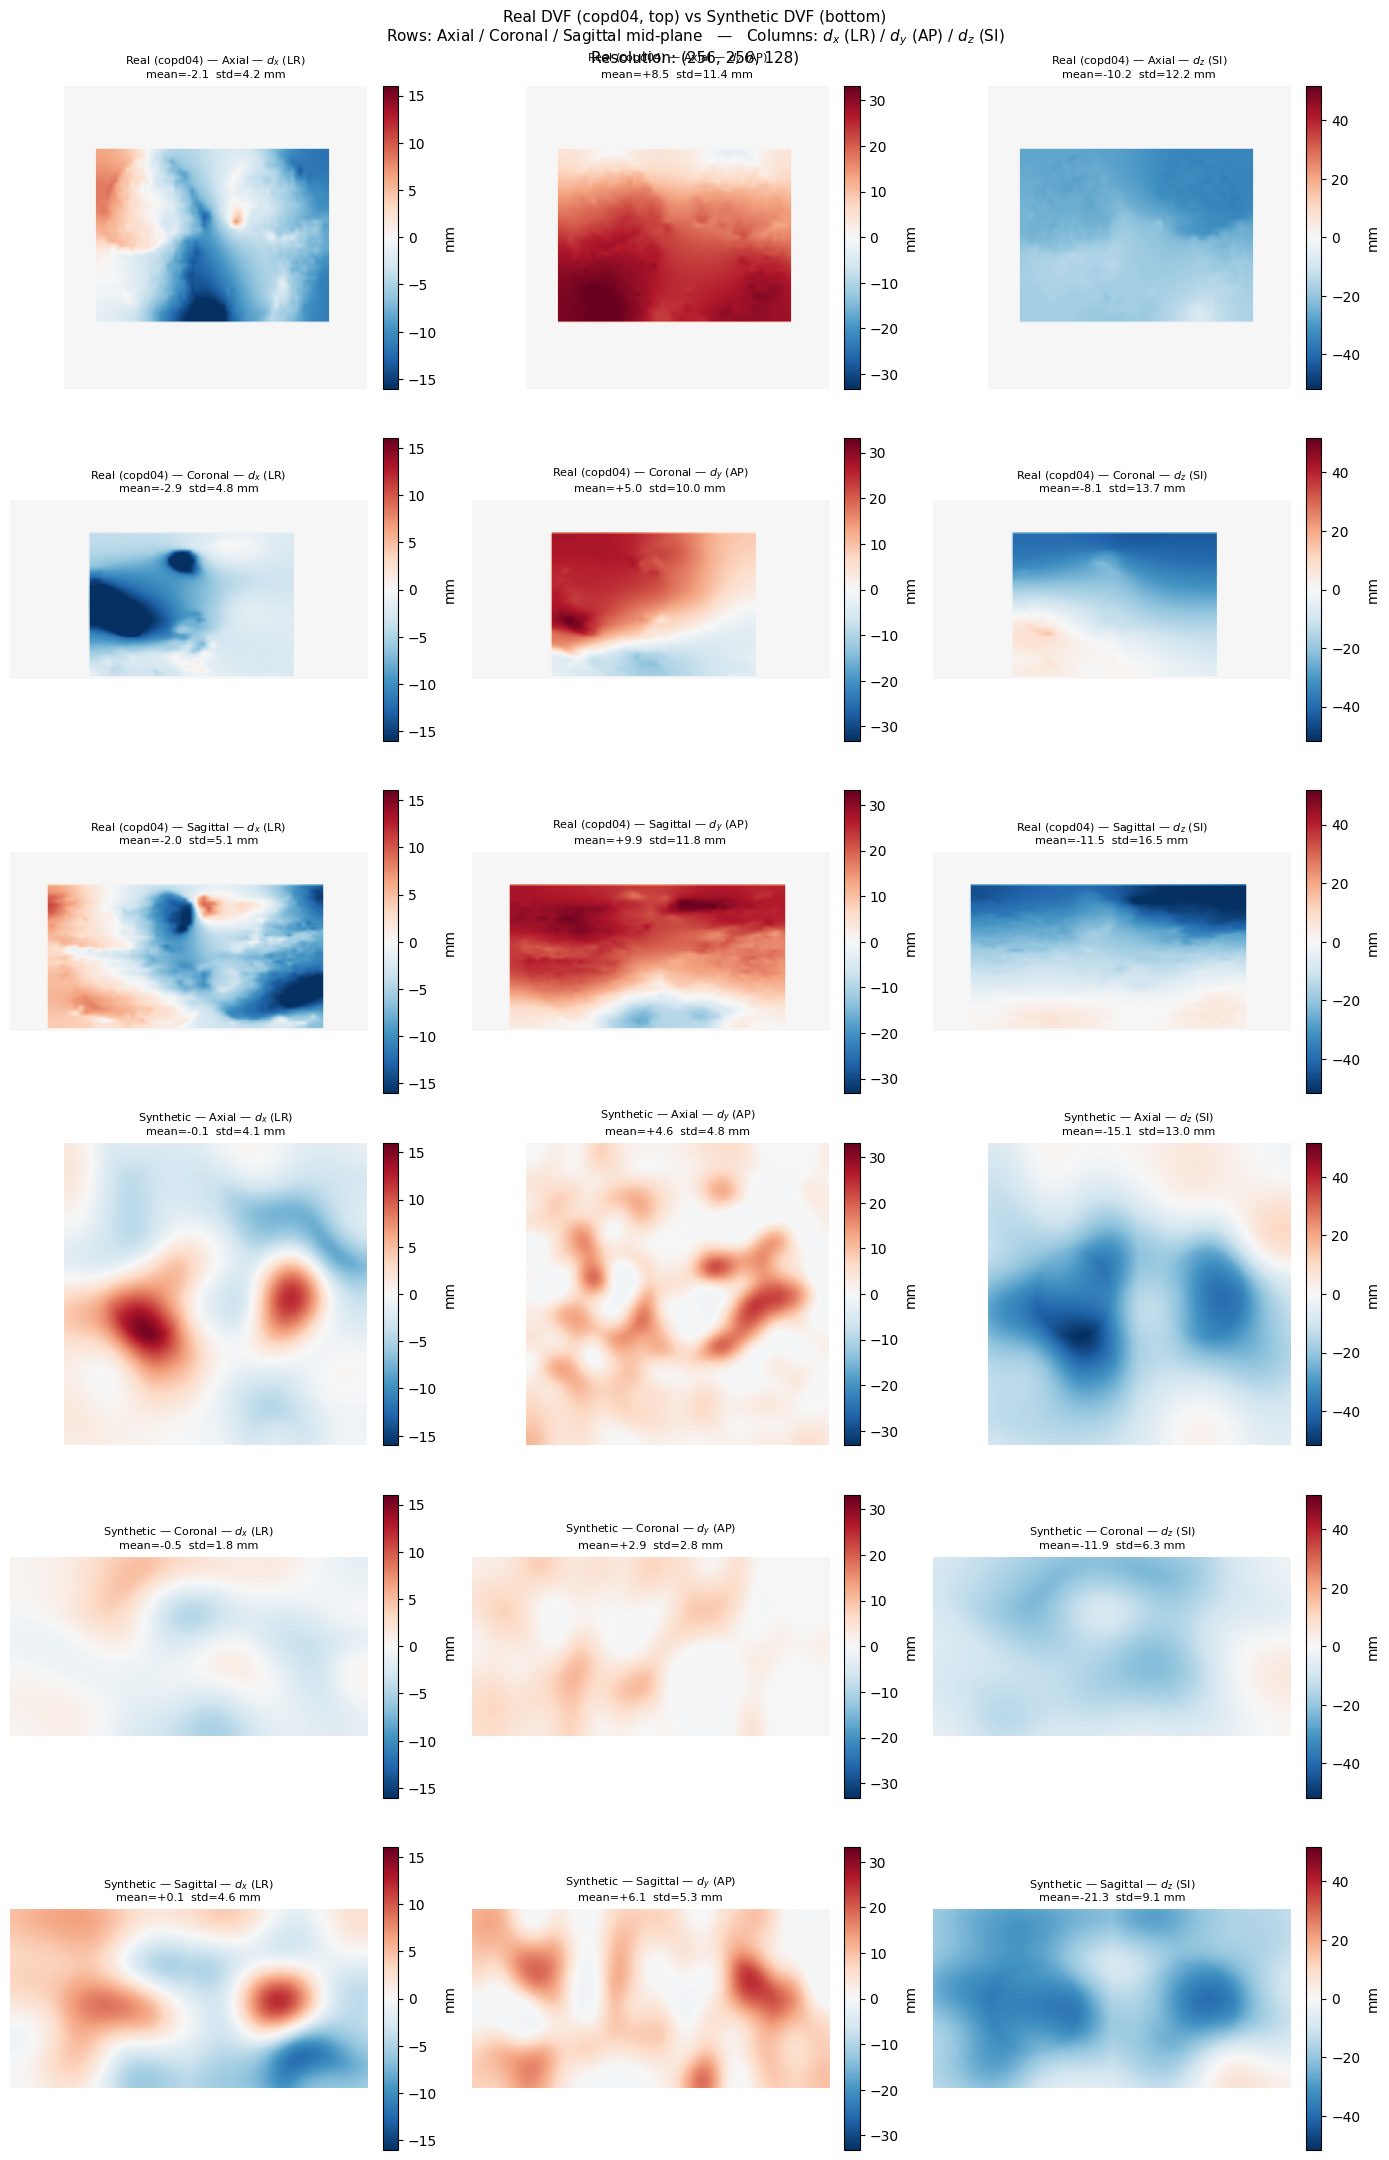

Saved to /mimer/NOBACKUP/groups/caim1/dafne/visual/real_vs_synthetic_dvf.png


In [12]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
import os

# ── Config ────────────────────────────────────────────────────────────────────
real_path  = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/real/fields/copd04.nii.gz"
synth_path = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/smooth_synthetic/train/b/field_00001.npy"
VIS_DIR    = "/mimer/NOBACKUP/groups/caim1/dafne/visual"
os.makedirs(VIS_DIR, exist_ok=True)

# ── Load real DVF and downsample to 256x256x128 ───────────────────────────────
img      = nib.load(real_path)
real_dvf = img.get_fdata(dtype=np.float32)  # (512, 512, ~120, 3)
scale    = (256 / real_dvf.shape[0],
            256 / real_dvf.shape[1],
            128 / real_dvf.shape[2],
            1.0)
real_dvf = zoom(real_dvf, scale, order=1)   # (256, 256, 128, 3)

# ── Load synthetic DVF at native resolution (256x256x128) ────────────────────
synth_dvf = np.load(synth_path).transpose(1, 2, 3, 0)  # (256, 256, 128, 3)

# ── Shared colormap range per component for fair comparison ───────────────────
names = ["$d_x$ (LR)", "$d_y$ (AP)", "$d_z$ (SI)"]
vmaxs = [max(np.percentile(np.abs(real_dvf[..., c]), 99),
             np.percentile(np.abs(synth_dvf[..., c]), 99))
         for c in range(3)]

# ── Mid-plane slices ──────────────────────────────────────────────────────────
def get_slices(dvf):
    H, W, D, _ = dvf.shape
    return [
        ("Axial",    dvf[:, :, D//2, :]),
        ("Coronal",  dvf[H//2, :, :, :]),
        ("Sagittal", dvf[:, W//2, :, :]),
    ]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(6, 3, figsize=(14, 22))
fig.suptitle("Real DVF (copd04, top) vs Synthetic DVF (bottom)\n"
             "Rows: Axial / Coronal / Sagittal mid-plane   —   "
             "Columns: $d_x$ (LR) / $d_y$ (AP) / $d_z$ (SI)\n"
             f"Resolution: {real_dvf.shape[:3]}",
             fontsize=11)

for dvf, row_offset, label in [
    (real_dvf,  0, "Real (copd04)"),
    (synth_dvf, 3, "Synthetic"),
]:
    for row, (view_name, sl_data) in enumerate(get_slices(dvf)):
        for col in range(3):
            ax = axes[row + row_offset][col]
            sl = sl_data[:, :, col]
            im = ax.imshow(sl.T, cmap='RdBu_r',
                           vmin=-vmaxs[col], vmax=vmaxs[col],
                           origin='lower')
            ax.set_title(f"{label} — {view_name} — {names[col]}\n"
                         f"mean={sl.mean():+.1f}  std={sl.std():.1f} mm",
                         fontsize=8)
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='mm')

plt.tight_layout()
save_path = os.path.join(VIS_DIR, "real_vs_synthetic_dvf.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {save_path}")

In [5]:
import numpy as np

synth_path = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/smooth_synthetic_downsampled/train/b/field_00000.npy"
data = np.load(synth_path)

print(f"Shape: {data.shape}")
print(f"dtype: {data.dtype}")
print(f"min: {data.min():.3f}  max: {data.max():.3f}")
print(f"mean: {data.mean():.3f}  std: {data.std():.3f}")
for c, name in enumerate(["dx", "dy", "dz"]):
    print(f"  {name}: mean={data[c].mean():+.2f}  std={data[c].std():.2f}  max|abs|={np.abs(data[c]).max():.2f}")

Shape: (3, 128, 128, 64)
dtype: float32
min: -4.783  max: 3.833
mean: -0.014  std: 0.963
  dx: mean=+0.25  std=0.32  max|abs|=1.63
  dy: mean=+0.63  std=0.45  max|abs|=3.83
  dz: mean=-0.93  std=1.07  max|abs|=4.78


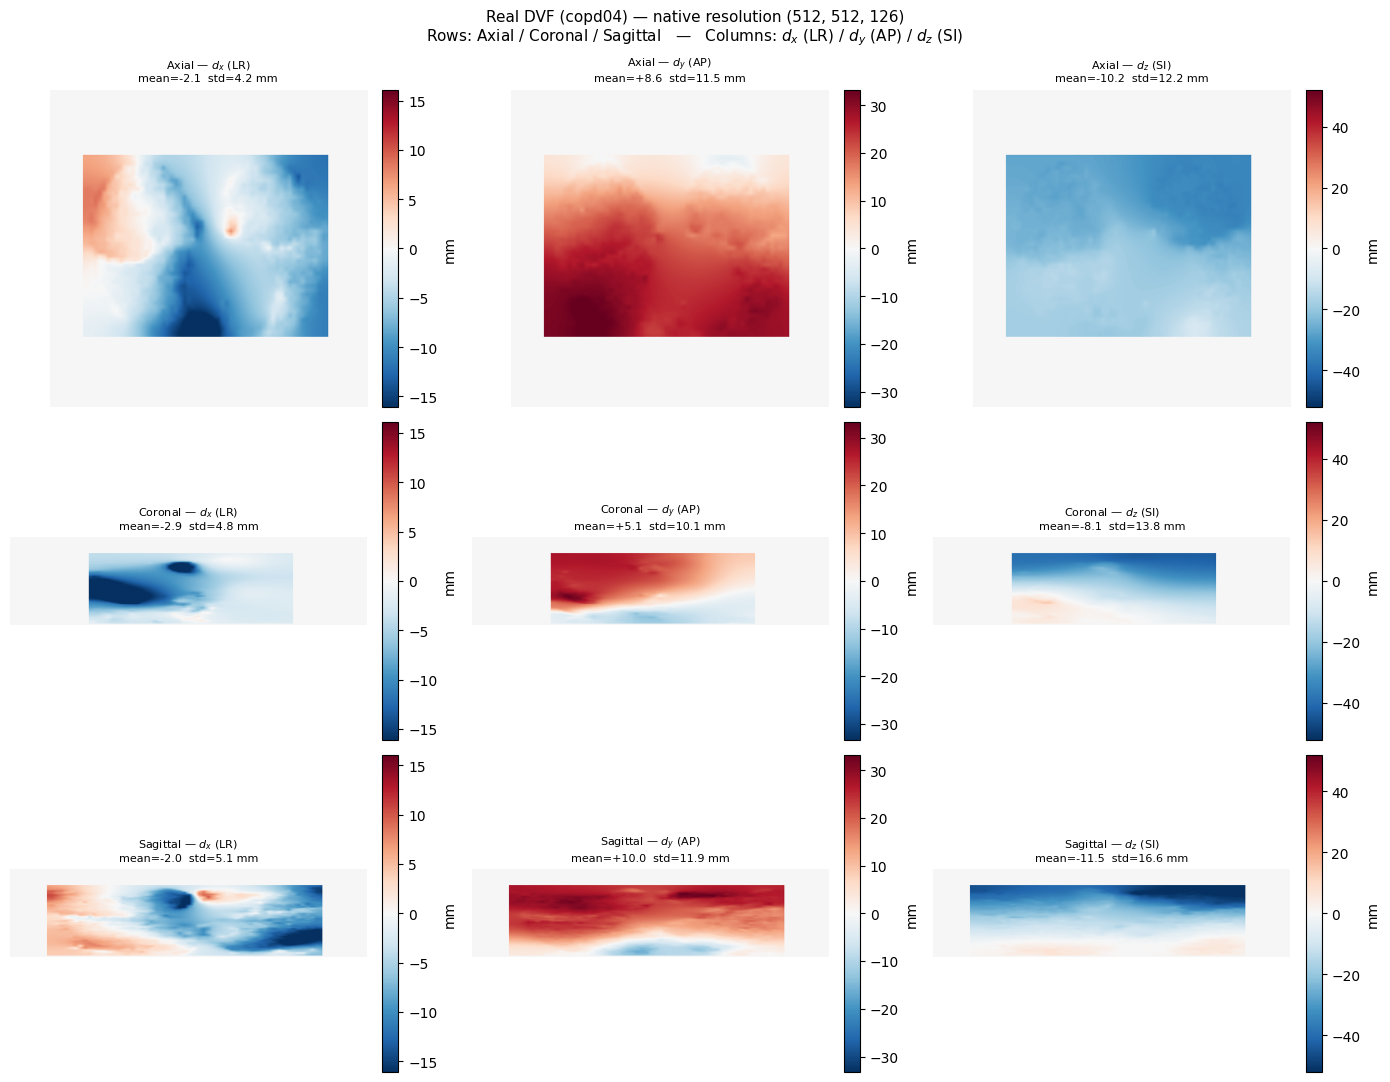

Saved to /mimer/NOBACKUP/groups/caim1/dafne/visual/real_dvf_native.png


In [13]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import os

# ── Config ────────────────────────────────────────────────────────────────────
real_path = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/real/fields/copd04.nii.gz"
VIS_DIR   = "/mimer/NOBACKUP/groups/caim1/dafne/visual"
os.makedirs(VIS_DIR, exist_ok=True)

# ── Load real DVF at native resolution ───────────────────────────────────────
img      = nib.load(real_path)
real_dvf = img.get_fdata(dtype=np.float32)  # (512, 512, ~120, 3)

# ── Mid-plane slices ──────────────────────────────────────────────────────────
names = ["$d_x$ (LR)", "$d_y$ (AP)", "$d_z$ (SI)"]
H, W, D, _ = real_dvf.shape
views = [
    ("Axial",    real_dvf[:, :, D//2, :]),
    ("Coronal",  real_dvf[H//2, :, :, :]),
    ("Sagittal", real_dvf[:, W//2, :, :]),
]
vmaxs = [np.percentile(np.abs(real_dvf[..., c]), 99) for c in range(3)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
fig.suptitle(f"Real DVF (copd04) — native resolution {real_dvf.shape[:3]}\n"
             "Rows: Axial / Coronal / Sagittal   —   "
             "Columns: $d_x$ (LR) / $d_y$ (AP) / $d_z$ (SI)",
             fontsize=11)

for row, (view_name, sl_data) in enumerate(views):
    for col in range(3):
        ax = axes[row][col]
        sl = sl_data[:, :, col]
        im = ax.imshow(sl.T, cmap='RdBu_r',
                       vmin=-vmaxs[col], vmax=vmaxs[col],
                       origin='lower')
        ax.set_title(f"{view_name} — {names[col]}\n"
                     f"mean={sl.mean():+.1f}  std={sl.std():.1f} mm",
                     fontsize=8)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='mm')

plt.tight_layout()
save_path = os.path.join(VIS_DIR, "synth_dvf_native.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {save_path}")

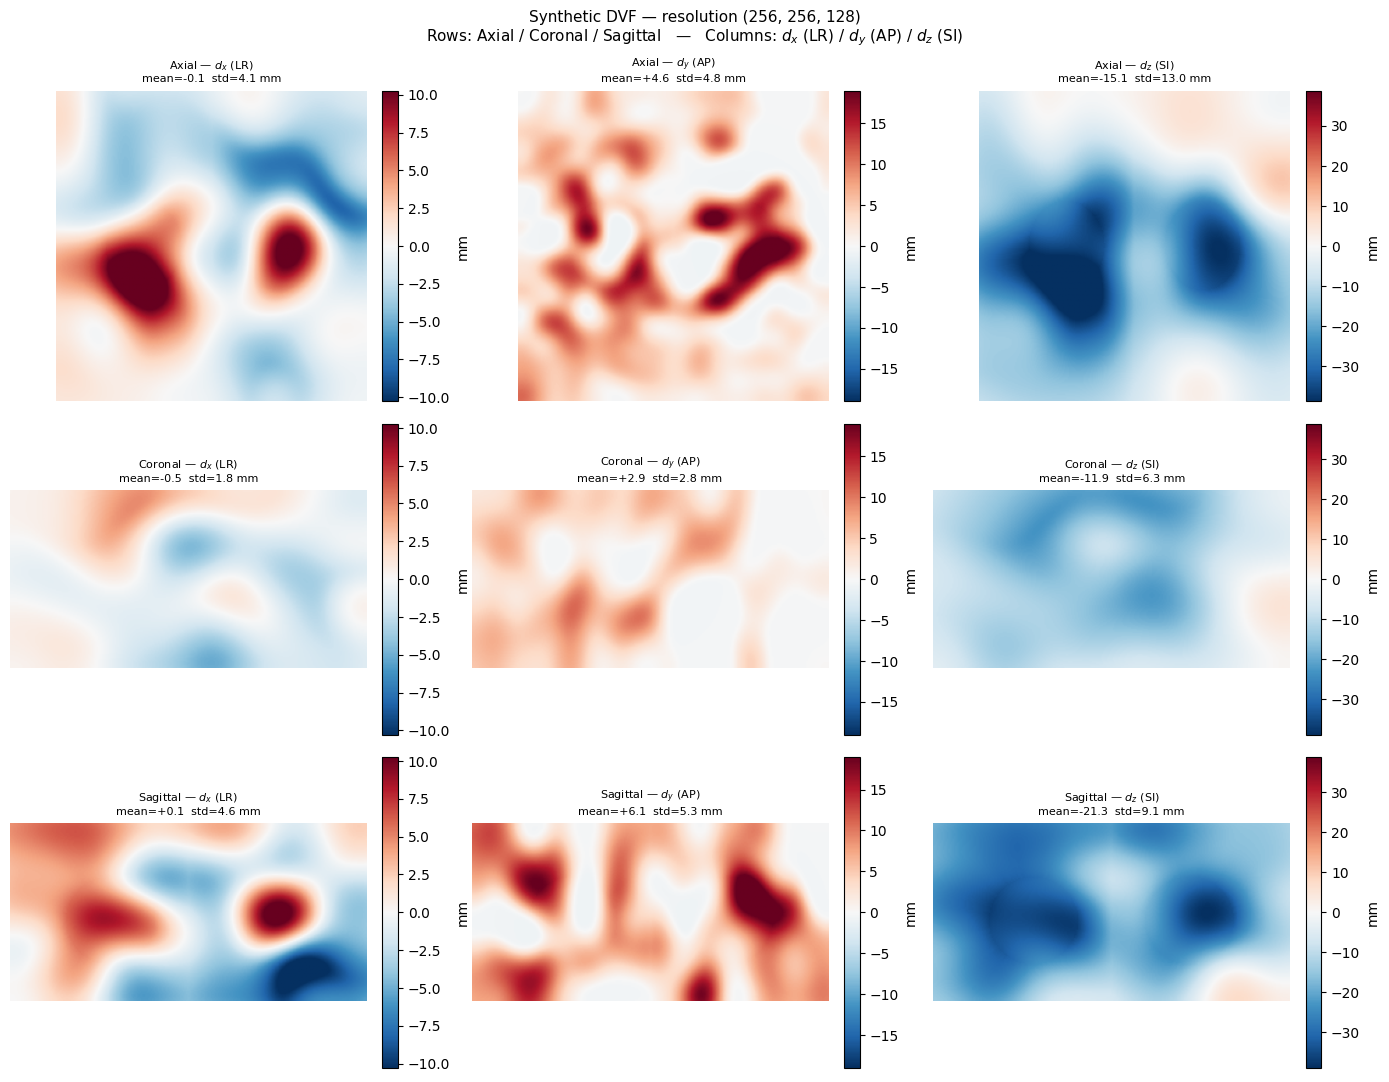

Saved to /mimer/NOBACKUP/groups/caim1/dafne/visual/synth_dvf_native.png


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Config ────────────────────────────────────────────────────────────────────
synth_path = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/smooth_synthetic/train/b/field_00001.npy"
VIS_DIR    = "/mimer/NOBACKUP/groups/caim1/dafne/visual"
os.makedirs(VIS_DIR, exist_ok=True)

# ── Load synthetic DVF at native resolution (256x256x128) ────────────────────
synth_dvf = np.load(synth_path).transpose(1, 2, 3, 0)  # (256, 256, 128, 3)

# ── Mid-plane slices ──────────────────────────────────────────────────────────
names = ["$d_x$ (LR)", "$d_y$ (AP)", "$d_z$ (SI)"]
H, W, D, _ = synth_dvf.shape
views = [
    ("Axial",    synth_dvf[:, :, D//2, :]),
    ("Coronal",  synth_dvf[H//2, :, :, :]),
    ("Sagittal", synth_dvf[:, W//2, :, :]),
]
vmaxs = [np.percentile(np.abs(synth_dvf[..., c]), 99) for c in range(3)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
fig.suptitle(f"Synthetic DVF — resolution {synth_dvf.shape[:3]}\n"
             "Rows: Axial / Coronal / Sagittal   —   "
             "Columns: $d_x$ (LR) / $d_y$ (AP) / $d_z$ (SI)",
             fontsize=11)

for row, (view_name, sl_data) in enumerate(views):
    for col in range(3):
        ax = axes[row][col]
        sl = sl_data[:, :, col]
        im = ax.imshow(sl.T, cmap='RdBu_r',
                       vmin=-vmaxs[col], vmax=vmaxs[col],
                       origin='lower')
        ax.set_title(f"{view_name} — {names[col]}\n"
                     f"mean={sl.mean():+.1f}  std={sl.std():.1f} mm",
                     fontsize=8)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='mm')

plt.tight_layout()
save_path = os.path.join(VIS_DIR, "synth_dvf_native.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {save_path}")

In [16]:
"""
visualize_slice_positions.py
─────────────────────────────
Shows the 4 candidate conditioning slice positions (H=32,48,64,80)
on both the CT image and the DVF magnitude, so you can check
which ones actually fall inside the lung (non-zero DVF region).
"""

import os
import numpy as np
import nibabel as nib
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# ── Config ────────────────────────────────────────────────────────────────────
CASE_IDX   = 1   # change to check different cases
FIELDS_DIR = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/real/fields"
CT_DIR     = "/mimer/NOBACKUP/groups/caim1/dafne/datasets/real/ct_images"
OUT_PATH   = "/mimer/NOBACKUP/groups/caim1/dafne/visual_analysis/slice_positions.png"
DS_SHAPE   = (128, 128, 64)
CT_VMIN, CT_VMAX = -1000, 400

CASE_DIMS = {
    "copd1":  (512, 512, 121), "copd2":  (512, 512, 102),
    "copd3":  (512, 512, 126), "copd4":  (512, 512, 126),
    "copd5":  (512, 512, 131), "copd6":  (512, 512, 119),
    "copd7":  (512, 512, 112), "copd8":  (512, 512, 115),
    "copd9":  (512, 512, 116), "copd10": (512, 512, 135),
}

SLICE_FRACTIONS = [0.25, 0.375, 0.5, 0.625]

case_name_pad   = f"copd{CASE_IDX + 1:02d}"
case_name_nopad = f"copd{CASE_IDX + 1}"
H, W, D = DS_SHAPE
cor_indices = [int(f * H) for f in SLICE_FRACTIONS]   # [32, 48, 64, 80]
sag_indices = [int(f * W) for f in SLICE_FRACTIONS]

print(f"Case: {case_name_pad}")
print(f"Coronal   H indices: {cor_indices}")
print(f"Sagittal  W indices: {sag_indices}")

# ── Load DVF ──────────────────────────────────────────────────────────────────
dvf = nib.load(os.path.join(FIELDS_DIR, f"{case_name_pad}.nii.gz")).get_fdata().astype(np.float32)
dvf = dvf[..., [0, 2, 1]].transpose(3, 0, 1, 2)
dvf_t = torch.from_numpy(dvf)
Dv = dvf_t.shape[-1]
if Dv < 128:
    pad = 128 - Dv
    dvf_t = F.pad(dvf_t, (pad//2, pad - pad//2))
elif Dv > 128:
    c = (Dv - 128) // 2
    dvf_t = dvf_t[..., c:c+128]
dvf_t  = F.interpolate(dvf_t.unsqueeze(0), size=DS_SHAPE, mode='trilinear', align_corners=False).squeeze(0)
dvf_np = dvf_t.numpy()   # (3, 128, 128, 64)

# DVF magnitude (H, W, D)
mag = np.sqrt((dvf_np**2).sum(axis=0))

# ── Load CT ───────────────────────────────────────────────────────────────────
ct_dims = CASE_DIMS[case_name_nopad]
ct = np.fromfile(
    os.path.join(CT_DIR, case_name_nopad, f"{case_name_nopad}_eBHCT.img"),
    dtype=np.int16).reshape(ct_dims, order='F').astype(np.float32)
Dct = ct.shape[2]
if Dct < 128:
    pad = 128 - Dct
    ct = np.pad(ct, ((0,0),(0,0),(pad//2, pad - pad//2)))
elif Dct > 128:
    c = (Dct - 128) // 2
    ct = ct[:, :, c:c+128]
ct_ds = ct[::4, ::4, ::2]   # (128, 128, 64)

# ── Non-zero fraction per coronal slice ───────────────────────────────────────
print("\nNon-zero DVF fraction per coronal H slice:")
for h in cor_indices:
    nz = (mag[h, :, :] > 0.5).mean() * 100
    print(f"  H={h:3d}  non-zero: {nz:.1f}%")

print("\nNon-zero DVF fraction per sagittal W slice:")
for w in sag_indices:
    nz = (mag[:, w, :] > 0.5).mean() * 100
    print(f"  W={w:3d}  non-zero: {nz:.1f}%")

# ── Plot ──────────────────────────────────────────────────────────────────────
# Layout: 2 blocks (coronal, sagittal) × 4 positions
# Each block: CT slice | DVF magnitude slice  side by side
n_pos = len(cor_indices)
fig, axes = plt.subplots(2 * 2, n_pos, figsize=(n_pos * 3.5, 10))
fig.suptitle(
    f"{case_name_pad.upper()} — Conditioning slice positions\n"
    f"Coronal H={cor_indices}  ·  Sagittal W={sag_indices}",
    fontsize=13, fontweight='bold'
)

vmax_mag = np.percentile(mag[mag > 0.5], 99) if (mag > 0.5).any() else 1.0

def show(ax, img, title, cmap, vmin, vmax):
    im = ax.imshow(img.T, cmap=cmap, origin='lower', aspect='auto',
                   vmin=vmin, vmax=vmax, interpolation='bilinear')
    ax.set_title(title, fontsize=8, pad=3)
    ax.axis('off')
    return im

# Row 0: CT at coronal H slices
# Row 1: DVF mag at coronal H slices
# Row 2: CT at sagittal W slices
# Row 3: DVF mag at sagittal W slices

row_labels = ["Coronal CT", "Coronal DVF mag", "Sagittal CT", "Sagittal DVF mag"]
for ri, label in enumerate(row_labels):
    axes[ri, 0].set_ylabel(label, fontsize=9, rotation=90, labelpad=4)

for pi, (h, w) in enumerate(zip(cor_indices, sag_indices)):
    nz_cor = (mag[h, :, :] > 0.5).mean() * 100
    nz_sag = (mag[:, w, :] > 0.5).mean() * 100

    # Coronal CT (slice along H axis → shows W×D plane)
    show(axes[0, pi], ct_ds[h, :, :],
         f"H={h}  ({nz_cor:.0f}% lung)", 'gray', CT_VMIN, CT_VMAX)

    # Coronal DVF mag
    im = show(axes[1, pi], mag[h, :, :],
              f"H={h}  mag", 'inferno', 0, vmax_mag)

    # Sagittal CT (slice along W axis → shows H×D plane)
    show(axes[2, pi], ct_ds[:, w, :],
         f"W={w}  ({nz_sag:.0f}% lung)", 'gray', CT_VMIN, CT_VMAX)

    # Sagittal DVF mag
    show(axes[3, pi], mag[:, w, :],
         f"W={w}  mag", 'inferno', 0, vmax_mag)

plt.tight_layout()
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
plt.savefig(OUT_PATH, dpi=130, bbox_inches='tight')
plt.close()
print(f"\nSaved: {OUT_PATH}")

Case: copd02
Coronal   H indices: [32, 48, 64, 80]
Sagittal  W indices: [32, 48, 64, 80]

Non-zero DVF fraction per coronal H slice:
  H= 32  non-zero: 41.4%
  H= 48  non-zero: 41.4%
  H= 64  non-zero: 41.4%
  H= 80  non-zero: 41.4%

Non-zero DVF fraction per sagittal W slice:
  W= 32  non-zero: 51.6%
  W= 48  non-zero: 51.6%
  W= 64  non-zero: 51.6%
  W= 80  non-zero: 51.6%

Saved: /mimer/NOBACKUP/groups/caim1/dafne/visual_analysis/slice_positions.png
